In [1]:
import warnings
warnings.simplefilter(action="ignore")
# conda install -c conda-forge sweetviz
#!pip install sweetviz

In [2]:
!pip install numpy==1.26.4


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install sweetviz


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install seaborn matplotlib scipy

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   -------- ------------------------------ 61.4/294.9 kB 812.7 kB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Análisis Exploratório de Datos con Python/Pandas

_Python_ es un lenguaje de programación de alto nivel que se puede utilizar para realizar varias tareas. En este curso utilizaremos _Python_ y algunas de sus librerías para realizar actividades prácticas relacionadas con la Minería de Datos.

Una distribución de _Python_ gratuita (para uso individual) que es fácil de instalar y mantener es [Anaconda](https://www.anaconda.com/products/individual).

Si no puede instalar _Python_ en su máquina, puede usar una versión en línea como [Google Colab](https://colab.research.google.com)

Hoy usaremos la biblioteca [_Pandas_](https://pandas.pydata.org/), que es una biblioteca de análisis y manipulación de datos de código abierto rápida, potente, flexible y fácil de usar.

In [5]:
import pandas as pd # cargar y manipular datos
import sweetviz as sv # herramienta de análisis exploratória
import seaborn as sns # gráficos
import matplotlib.pyplot as plt # gráficos
import numpy as np # procesamiento matemático
from scipy.stats import norm # normal

Comencemos cargando Pandas y la base de datos. Esta es una base para el pago de facturas en un restaurante y cuenta como atributos la factura total (total_bill), la propina (tip), el sexo del cliente que paga (sex), si la mesa estaba en un área de fumadores (smoker), el día de la semana (day) y la cantidad de personas en la mesa (size).

## 1.- Realizar el EDA utilizando la herramienta sweetviz del siguiente dataset.
https://raw.githubusercontent.com/ProjectMOSAIC/NHANES/master/data-raw/NHANES.csv

In [6]:
tips = pd.read_csv("https://raw.githubusercontent.com/ProjectMOSAIC/NHANES/master/data-raw/NHANES.csv",index_col=0)

## Limpieza de datos: Eliminar columnas con más del 60% de valores faltantes

In [7]:
# Verificar el porcentaje de valores faltantes antes de la limpieza
print("Dataset original:")
print(f"Forma del dataset: {tips.shape}")
print("\nPorcentaje de valores faltantes por columna:")

# Calcular porcentaje de valores faltantes
missing_percent = (tips.isnull().sum() / len(tips)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

# Mostrar todas las columnas con sus porcentajes de missing
for col, percent in missing_percent.items():
    print(f"{col}: {percent:.1f}%")

Dataset original:
Forma del dataset: (10000, 74)

Porcentaje de valores faltantes por columna:
HeadCirc: 99.1%
Length: 94.6%
DiabetesAge: 93.7%
CompHrsDayChild: 93.5%
TVHrsDayChild: 93.5%
BMICatUnder20yrs: 87.3%
AgeRegMarij: 86.3%
Depressed: 85.7%
UrineFlow2: 85.2%
UrineVol2: 85.2%
LittleInterest: 84.4%
Age1stBaby: 81.2%
nBabies: 75.8%
nPregnancies: 74.0%
AgeFirstMarij: 71.1%
SmokeAge: 69.2%
SmokeNow: 67.9%
Testosterone: 58.7%
PhysActiveDays: 53.4%
SexOrientation: 51.6%
TVHrsDay: 51.4%
CompHrsDay: 51.4%
AlcoholDay: 50.9%
SexNumPartYear: 50.7%
RegularMarij: 50.6%
Marijuana: 50.6%
AgeMonths: 50.4%
Race3: 50.0%
SexAge: 44.6%
SexNumPartnLife: 42.8%
HardDrugs: 42.4%
SexEver: 42.3%
SameSex: 42.3%
AlcoholYear: 40.8%
Alcohol12PlusYr: 34.2%
Education: 27.8%
MaritalStatus: 27.7%
Smoke100: 27.7%
Smoke100n: 27.7%
DaysPhysHlthBad: 24.7%
DaysMentHlthBad: 24.7%
HealthGen: 24.6%
SleepHrsNight: 22.4%
Work: 22.3%
SleepTrouble: 22.3%
BPSys1: 17.6%
BPDia1: 17.6%
PhysActive: 16.7%
BPSys2: 16.5%
BPDia2: 16.

In [8]:
# Identificar columnas con más del 60% de valores faltantes
threshold = 60  # 60% de umbral
columns_to_drop = missing_percent[missing_percent > threshold].index.tolist()

print(f"\nColumnas a eliminar (>60% missing):")
for col in columns_to_drop:
    print(f"- {col}: {missing_percent[col]:.1f}%")

print(f"\nTotal de columnas a eliminar: {len(columns_to_drop)}")


Columnas a eliminar (>60% missing):
- HeadCirc: 99.1%
- Length: 94.6%
- DiabetesAge: 93.7%
- CompHrsDayChild: 93.5%
- TVHrsDayChild: 93.5%
- BMICatUnder20yrs: 87.3%
- AgeRegMarij: 86.3%
- Depressed: 85.7%
- UrineFlow2: 85.2%
- UrineVol2: 85.2%
- LittleInterest: 84.4%
- Age1stBaby: 81.2%
- nBabies: 75.8%
- nPregnancies: 74.0%
- AgeFirstMarij: 71.1%
- SmokeAge: 69.2%
- SmokeNow: 67.9%

Total de columnas a eliminar: 17


In [9]:
# Eliminar las columnas con más del 60% de valores faltantes
tips_cleaned = tips.drop(columns=columns_to_drop)

print(f"\nDataset después de la limpieza:")
print(f"Forma original: {tips.shape}")
print(f"Forma después de limpieza: {tips_cleaned.shape}")
print(f"Columnas eliminadas: {tips.shape[1] - tips_cleaned.shape[1]}")

# Verificar el porcentaje de valores faltantes después de la limpieza
print(f"\nPorcentaje de valores faltantes después de la limpieza:")
missing_percent_cleaned = (tips_cleaned.isnull().sum() / len(tips_cleaned)) * 100
missing_percent_cleaned = missing_percent_cleaned[missing_percent_cleaned > 0].sort_values(ascending=False)

if len(missing_percent_cleaned) > 0:
    for col, percent in missing_percent_cleaned.items():
        print(f"{col}: {percent:.1f}%")
else:
    print("No hay columnas con valores faltantes en el dataset limpio.")


Dataset después de la limpieza:
Forma original: (10000, 74)
Forma después de limpieza: (10000, 57)
Columnas eliminadas: 17

Porcentaje de valores faltantes después de la limpieza:
Testosterone: 58.7%
PhysActiveDays: 53.4%
SexOrientation: 51.6%
TVHrsDay: 51.4%
CompHrsDay: 51.4%
AlcoholDay: 50.9%
SexNumPartYear: 50.7%
RegularMarij: 50.6%
Marijuana: 50.6%
AgeMonths: 50.4%
Race3: 50.0%
SexAge: 44.6%
SexNumPartnLife: 42.8%
HardDrugs: 42.4%
SexEver: 42.3%
SameSex: 42.3%
AlcoholYear: 40.8%
Alcohol12PlusYr: 34.2%
Education: 27.8%
MaritalStatus: 27.7%
Smoke100: 27.7%
Smoke100n: 27.7%
DaysPhysHlthBad: 24.7%
DaysMentHlthBad: 24.7%
HealthGen: 24.6%
SleepHrsNight: 22.4%
Work: 22.3%
SleepTrouble: 22.3%
BPSys1: 17.6%
BPDia1: 17.6%
PhysActive: 16.7%
BPDia2: 16.5%
BPSys2: 16.5%
BPDia3: 16.4%
BPSys3: 16.4%
UrineFlow1: 16.0%
TotChol: 15.3%
DirectChol: 15.3%
BPDiaAve: 14.5%
BPSysAve: 14.5%
Pulse: 14.4%
UrineVol1: 9.9%
HHIncomeMid: 8.1%
HHIncome: 8.1%
Poverty: 7.3%
BMI_WHO: 4.0%
BMI: 3.7%
Height: 3.5%
Age

In [10]:
# Actualizar la variable principal para usar el dataset limpio
tips = tips_cleaned.copy()

print("Dataset actualizado con datos limpios:")
print(f"Forma final: {tips.shape}")
print(f"Columnas disponibles: {list(tips.columns)}")

Dataset actualizado con datos limpios:
Forma final: (10000, 57)
Columnas disponibles: ['ID', 'Gender', 'Age', 'AgeDecade', 'AgeMonths', 'Race1', 'Race3', 'Education', 'MaritalStatus', 'HHIncome', 'HHIncomeMid', 'Poverty', 'HomeRooms', 'HomeOwn', 'Work', 'Weight', 'Height', 'BMI', 'BMI_WHO', 'Pulse', 'BPSysAve', 'BPDiaAve', 'BPSys1', 'BPDia1', 'BPSys2', 'BPDia2', 'BPSys3', 'BPDia3', 'Testosterone', 'DirectChol', 'TotChol', 'UrineVol1', 'UrineFlow1', 'Diabetes', 'HealthGen', 'DaysPhysHlthBad', 'DaysMentHlthBad', 'SleepHrsNight', 'SleepTrouble', 'PhysActive', 'PhysActiveDays', 'TVHrsDay', 'CompHrsDay', 'Alcohol12PlusYr', 'AlcoholDay', 'AlcoholYear', 'Smoke100', 'Smoke100n', 'Marijuana', 'RegularMarij', 'HardDrugs', 'SexEver', 'SexAge', 'SexNumPartnLife', 'SexNumPartYear', 'SameSex', 'SexOrientation']


### Resumen de la limpieza de datos

El proceso de limpieza consistió en:
1. **Identificación** de columnas con más del 60% de valores faltantes
2. **Eliminación** de estas columnas del dataset
3. **Actualización** del dataset principal para continuar con el análisis

Este proceso es importante porque:
- Mejora la calidad del análisis exploratorio
- Reduce el ruido en los datos
- Permite concentrarse en las variables con información más completa
- Evita conclusiones erróneas basadas en datos muy incompletos

Podemos ver las primeras líneas del archivo usando la función `.head ()`

In [11]:
tips_cleaned.head(10)

,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,HHIncome,...,Smoke100n,Marijuana,RegularMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
SurveyYr,,,,,,,,,,,,,,,,,,,,,
2009_10,55829,female,28,20-29,343.0,White,NaN,CollegeGrad,Married,more 99999,...,Non-Smoker,Yes,No,Yes,Yes,13.0,20.0,1.0,No,Heterosexual
2009_10,57112,male,14,10-19,170.0,White,NaN,NaN,NaN,75000-99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,60232,male,80,NaN,NaN,White,NaN,8thGrade,Married,20000-24999,...,Non-Smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,59919,male,22,20-29,268.0,White,NaN,HighSchool,NeverMarried,45000-54999,...,Smoker,Yes,Yes,Yes,Yes,18.0,3.0,1.0,No,Heterosexual
2009_10,56351,male,1,0-9,16.0,White,NaN,NaN,NaN,25000-34999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,56329,female,39,30-39,477.0,White,NaN,8thGrade,Married,15000-19999,...,Smoker,Yes,Yes,No,Yes,15.0,15.0,1.0,No,Heterosexual
2009_10,57197,male,18,10-19,223.0,White,NaN,NaN,NaN,75000-99999,...,NaN,No,No,No,No,NaN,0.0,0.0,No,Heterosexual
2009_10,52795,male,61,60-69,740.0,Other,NaN,SomeCollege,Married,10000-14999,...,Non-Smoker,NaN,NaN,No,Yes,13.0,3.0,NaN,No,NaN
2009_10,52719,female,73,70+,883.0,White,NaN,CollegeGrad,Married,75000-99999,...,Smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Los últimos con la función `.tail ()`

In [12]:
tips_cleaned.tail(10)

,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,HHIncome,...,Smoke100n,Marijuana,RegularMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
SurveyYr,,,,,,,,,,,,,,,,,,,,,
2011_12,71020,female,80,NaN,NaN,White,White,HighSchool,Widowed,10000-14999,...,Smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,62959,female,13,10-19,NaN,Other,Asian,NaN,NaN,more 99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,69393,male,33,30-39,NaN,Black,Black,SomeCollege,Married,75000-99999,...,Non-Smoker,Yes,No,No,Yes,19.0,3.0,1.0,No,Heterosexual
2011_12,68101,male,80,NaN,NaN,White,White,CollegeGrad,Married,15000-19999,...,Non-Smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,67366,female,5,0-9,NaN,White,White,NaN,NaN,20000-24999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,64065,male,46,40-49,NaN,White,White,SomeCollege,Married,more 99999,...,Non-Smoker,No,No,No,Yes,17.0,7.0,1.0,No,Heterosexual
2011_12,66189,male,47,40-49,NaN,Mexican,Mexican,9_11thGrade,Married,NaN,...,Non-Smoker,Yes,Yes,No,Yes,18.0,7.0,1.0,No,Heterosexual
2011_12,63714,male,48,40-49,NaN,White,White,SomeCollege,Married,more 99999,...,Non-Smoker,Yes,No,No,Yes,17.0,4.0,1.0,No,Heterosexual
2011_12,68501,male,52,50-59,NaN,White,White,SomeCollege,Married,45000-54999,...,Non-Smoker,Yes,Yes,Yes,Yes,16.0,50.0,1.0,No,Heterosexual


Y una muestra aleatoria con la función `.sample ()`

In [13]:
tips_cleaned.sample(10)

,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,HHIncome,...,Smoke100n,Marijuana,RegularMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
SurveyYr,,,,,,,,,,,,,,,,,,,,,
2009_10,55560,male,65,60-69,783.0,White,NaN,CollegeGrad,Married,more 99999,...,Non-Smoker,NaN,NaN,No,Yes,50.0,1.0,NaN,No,NaN
2009_10,53573,female,43,40-49,518.0,White,NaN,HighSchool,Married,75000-99999,...,Smoker,No,No,No,Yes,17.0,4.0,1.0,No,Heterosexual
2011_12,69641,female,23,20-29,NaN,White,White,HighSchool,NeverMarried,more 99999,...,Non-Smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,69051,female,5,0-9,NaN,White,White,NaN,NaN,more 99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,61207,female,71,70+,853.0,White,NaN,9_11thGrade,Widowed,10000-14999,...,Smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,53172,male,15,10-19,189.0,Black,NaN,NaN,NaN,75000-99999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009_10,56546,male,39,30-39,479.0,White,NaN,9_11thGrade,Married,75000-99999,...,Non-Smoker,No,No,No,Yes,16.0,13.0,1.0,No,Heterosexual
2011_12,69411,male,75,70+,NaN,White,White,CollegeGrad,Married,35000-44999,...,Non-Smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011_12,71054,female,51,50-59,NaN,White,White,HighSchool,LivePartner,65000-74999,...,Smoker,Yes,Yes,Yes,Yes,18.0,5.0,1.0,No,Heterosexual


O comando `.info()` mostra os atributos, e o tipos de cada atributo

## 2.- Escoger por lo menos una división de datos por alumno para examinar las particiones de datos.

In [14]:
tips_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 2009_10 to 2011_12
Data columns (total 57 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10000 non-null  int64  
 1   Gender           10000 non-null  object 
 2   Age              10000 non-null  int64  
 3   AgeDecade        9667 non-null   object 
 4   AgeMonths        4962 non-null   float64
 5   Race1            10000 non-null  object 
 6   Race3            5000 non-null   object 
 7   Education        7221 non-null   object 
 8   MaritalStatus    7231 non-null   object 
 9   HHIncome         9189 non-null   object 
 10  HHIncomeMid      9189 non-null   float64
 11  Poverty          9274 non-null   float64
 12  HomeRooms        9931 non-null   float64
 13  HomeOwn          9937 non-null   object 
 14  Work             7771 non-null   object 
 15  Weight           9922 non-null   float64
 16  Height           9647 non-null   float64
 17  BMI      

El comando `.describe ()` devuelve algunas estadísticas descriptivas para atributos numéricos:

In [15]:
tips_cleaned.describe()

,ID,Age,AgeMonths,HHIncomeMid,Poverty,HomeRooms,Weight,Height,BMI,Pulse,...,UrineFlow1,DaysPhysHlthBad,DaysMentHlthBad,SleepHrsNight,PhysActiveDays,AlcoholDay,AlcoholYear,SexAge,SexNumPartnLife,SexNumPartYear
count,10000.00000,10000.000000,4962.000000,9189.000000,9274.000000,9931.000000,9922.000000,9647.000000,9634.000000,8563.000000,...,8397.000000,7532.000000,7534.000000,7755.000000,4663.000000,4914.000000,5922.000000,5540.000000,5725.000000,4928.000000
mean,61944.64380,36.742100,420.123942,57206.170421,2.801844,6.248918,70.981798,161.877838,26.660136,73.559734,...,0.979295,3.334838,4.126493,6.927531,3.743513,2.914123,75.101655,17.428700,15.085066,1.342330
std,5871.16716,22.397566,259.043091,33020.276584,1.677909,2.277538,29.125357,20.186567,7.376579,12.155422,...,0.949514,7.400700,7.832971,1.346729,1.836358,3.182672,103.033738,3.716551,57.846434,2.782688
min,51624.00000,0.000000,0.000000,2500.000000,0.000000,1.000000,2.800000,83.600000,12.880000,40.000000,...,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000,9.000000,0.000000,0.000000
25%,56904.50000,17.000000,199.000000,30000.000000,1.240000,5.000000,56.100000,156.800000,21.580000,64.000000,...,0.403000,0.000000,0.000000,6.000000,2.000000,1.000000,3.000000,15.000000,2.000000,1.000000
50%,62159.50000,36.000000,418.000000,50000.000000,2.700000,6.000000,72.700000,166.000000,25.980000,72.000000,...,0.699000,0.000000,0.000000,7.000000,3.000000,2.000000,24.000000,17.000000,5.000000,1.000000
75%,67039.00000,54.000000,624.000000,87500.000000,4.710000,8.000000,88.900000,174.500000,30.890000,82.000000,...,1.221000,3.000000,4.000000,8.000000,5.000000,3.000000,104.000000,19.000000,12.000000,1.000000
max,71915.00000,80.000000,959.000000,100000.000000,5.000000,13.000000,230.700000,200.400000,81.250000,136.000000,...,17.167000,30.000000,30.000000,12.000000,7.000000,82.000000,364.000000,50.000000,2000.000000,69.000000


Echemos un vistazo a la distribución de la columna `total_bill`. Para facilitar la visualización, usaremos algunas bibliotecas de gráficos, como [`matplotlib`](https://matplotlib.org/) y [` seaborn`](https://seaborn.pydata.org/).

## 3.- Investigue como exportar el informe EDA en formato HTML.

##### Herramientas para agilizar el proceso

Calcular estadísticas manualmente invocando funciones y creando gráficos puede resultar bastante engorroso. Varias herramientas son capaces de generar informes estandarizados para análisis de datos exploratorios. Uno de ellos es `sweetviz`.

Feature: ID                                  |▏         | [  2%]   00:00 -> (00:02 left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:04 -> (00:00 left)




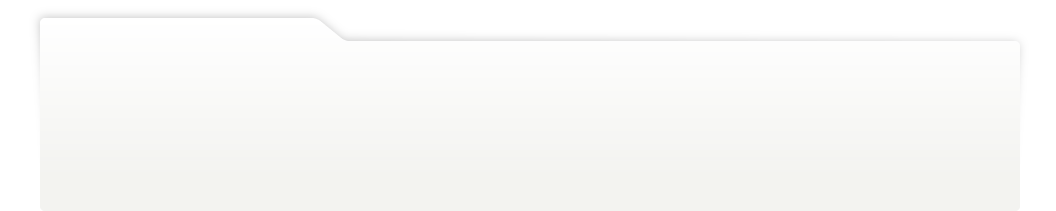
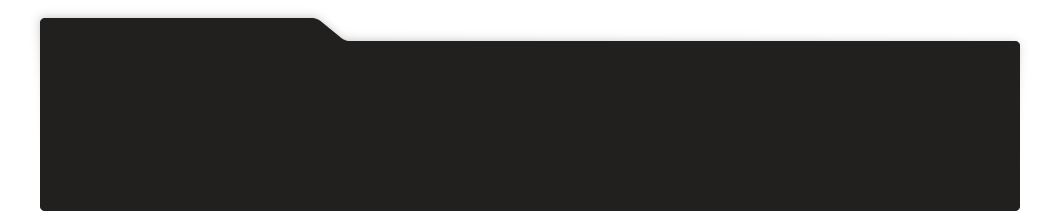
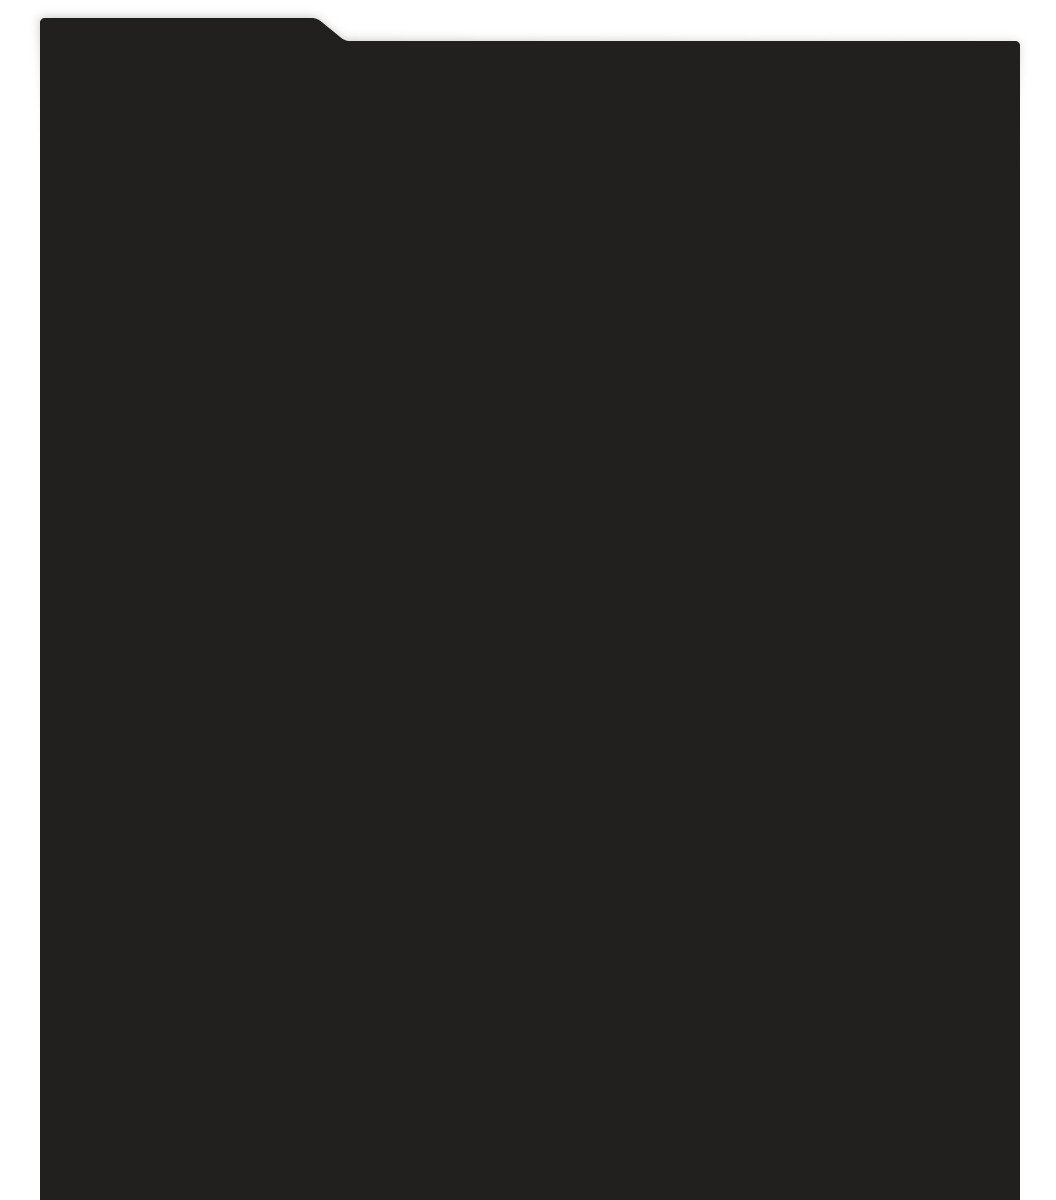
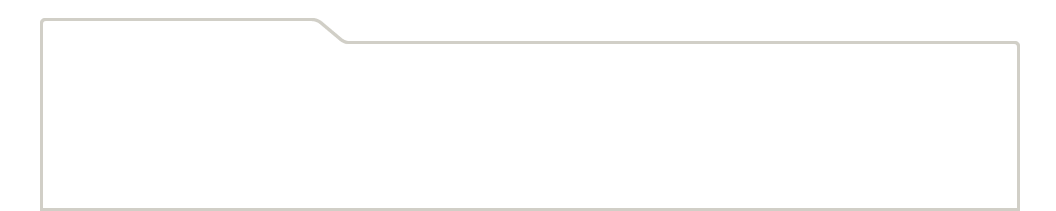
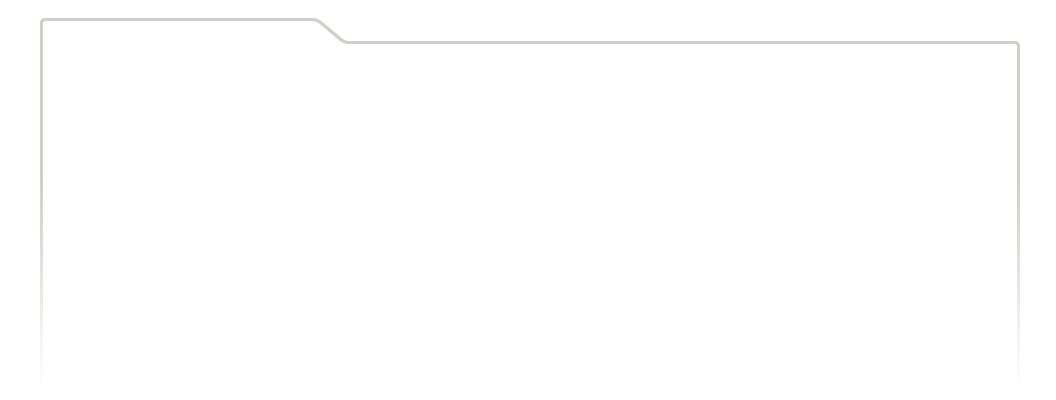
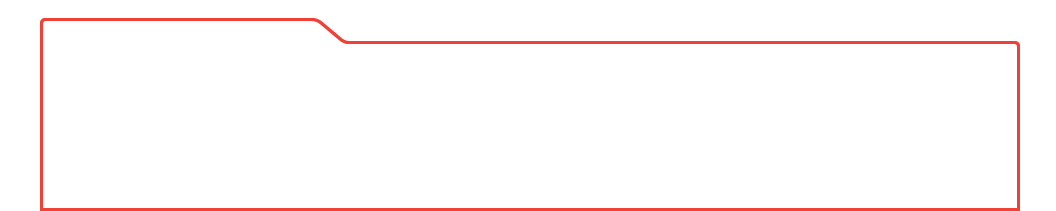
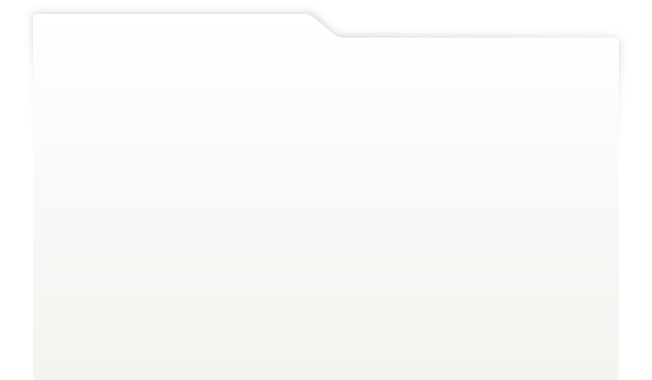
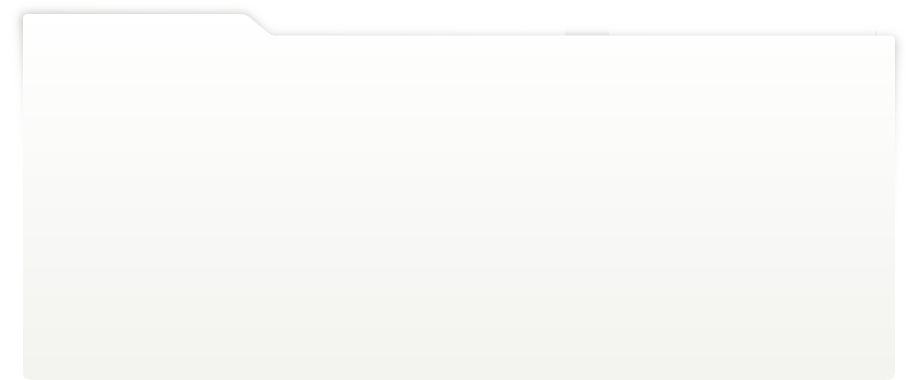
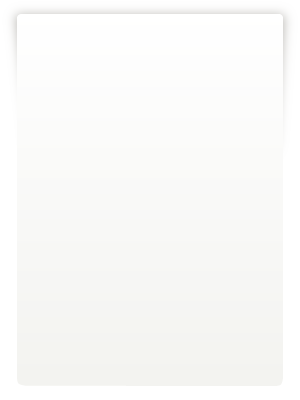
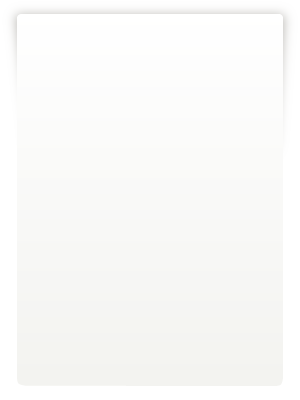
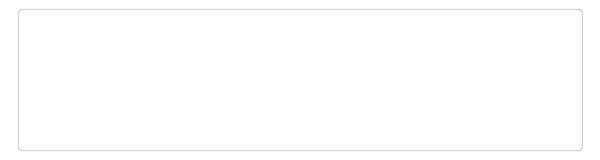
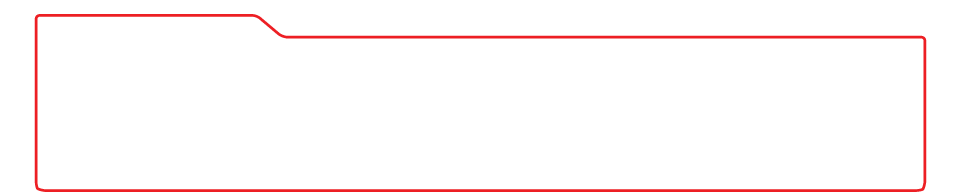
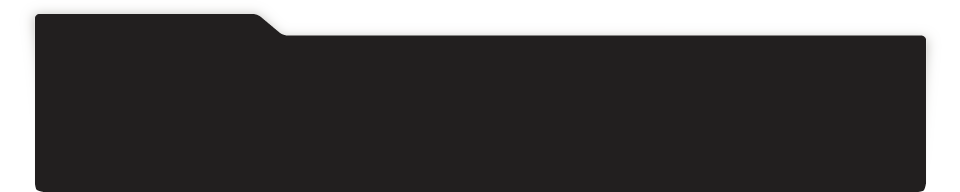
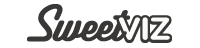
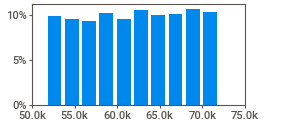
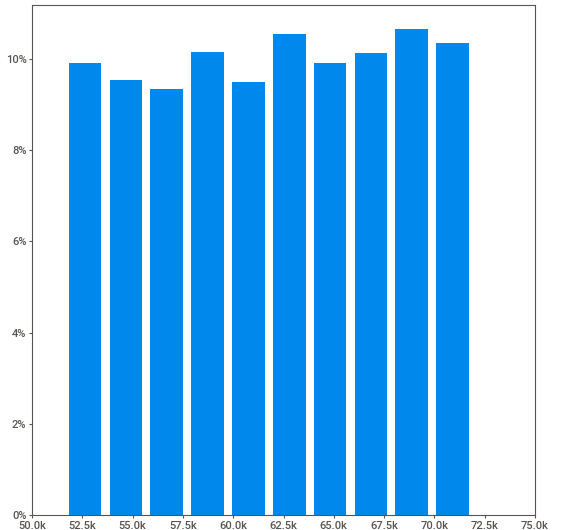
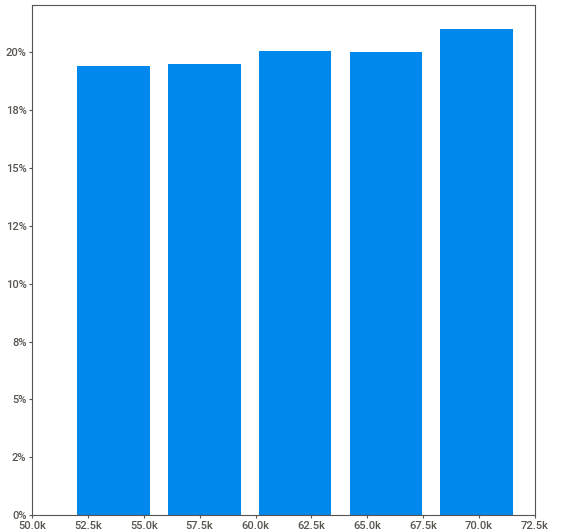
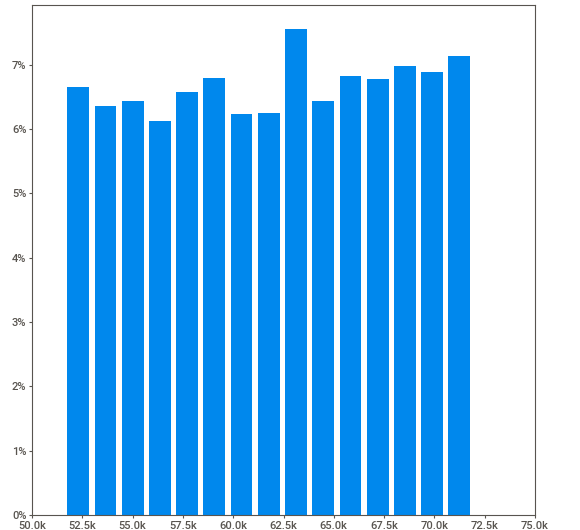
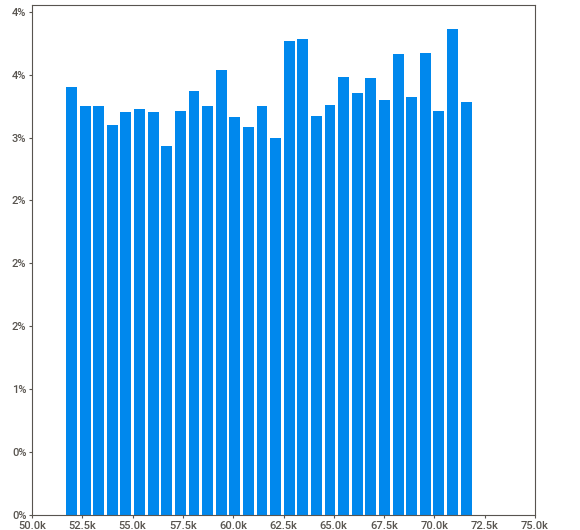
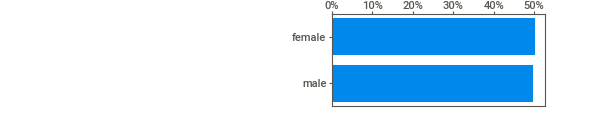
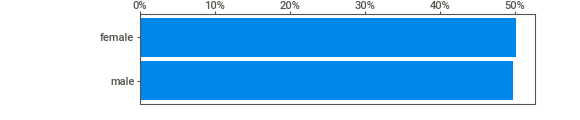
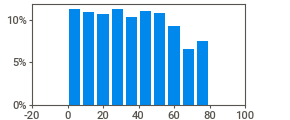
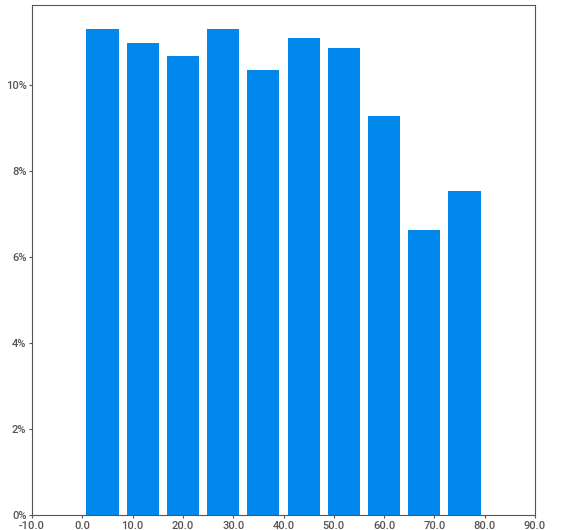
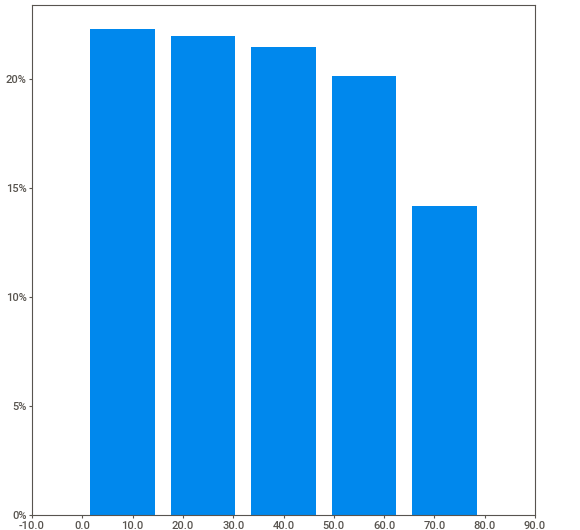
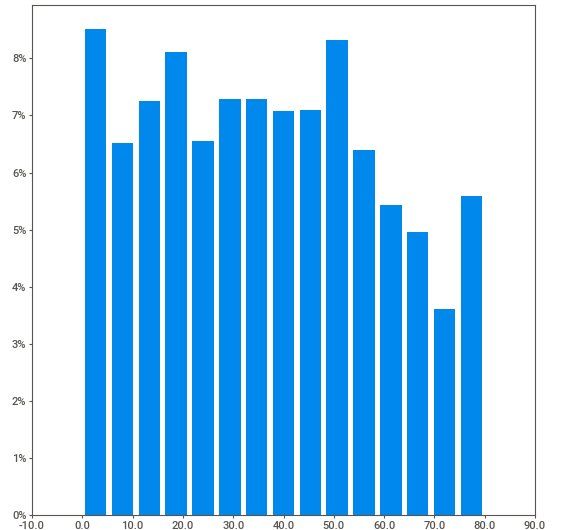
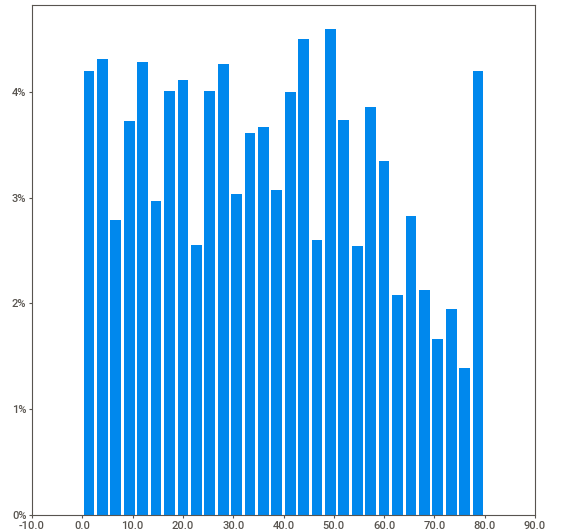
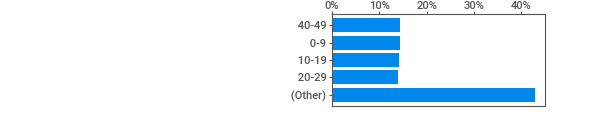
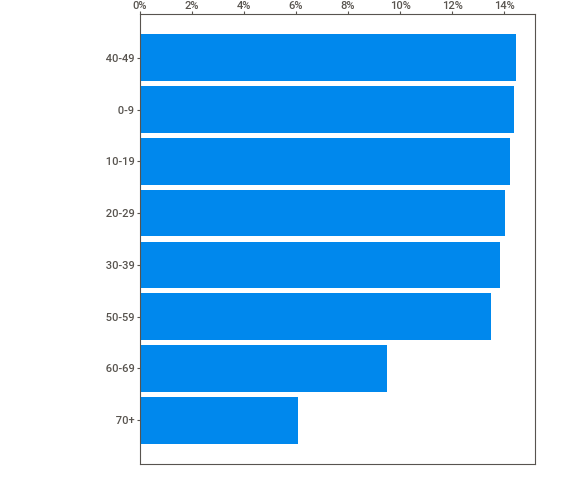
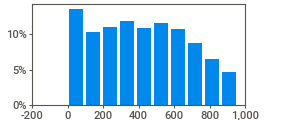
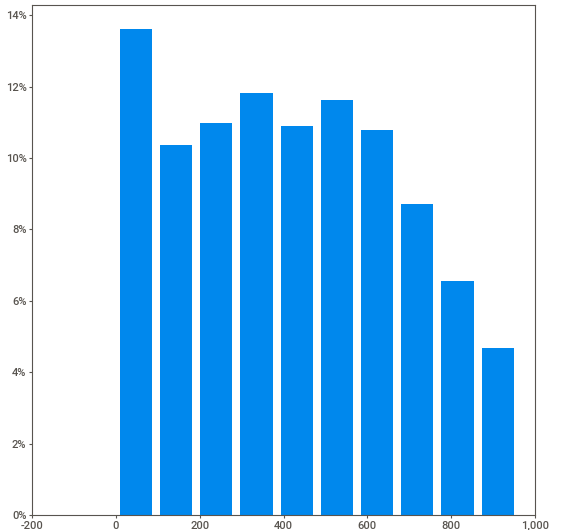
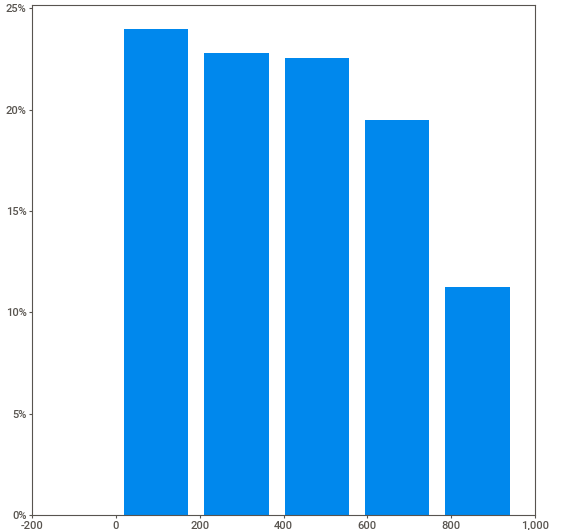
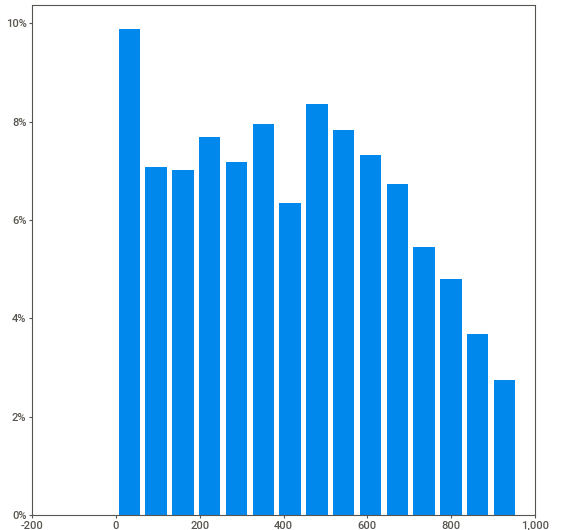
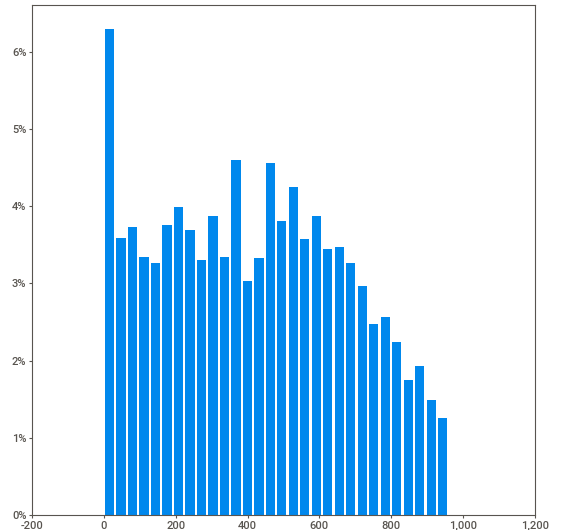
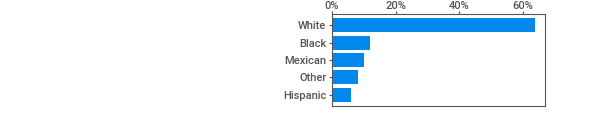
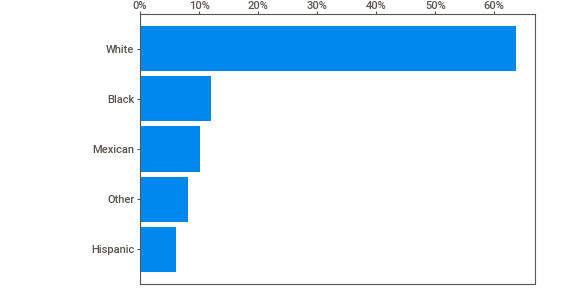
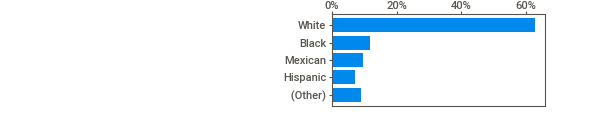
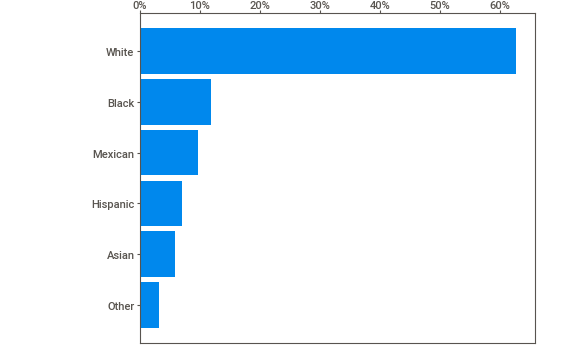
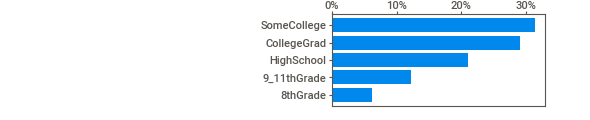
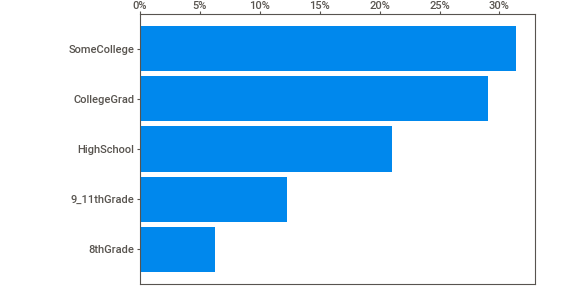
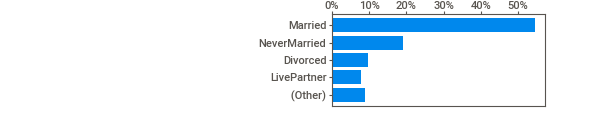
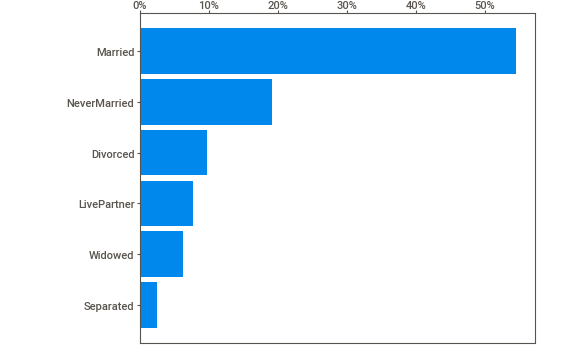
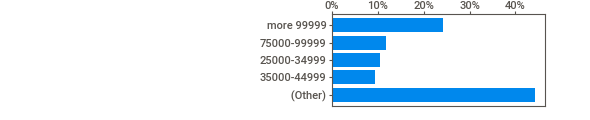
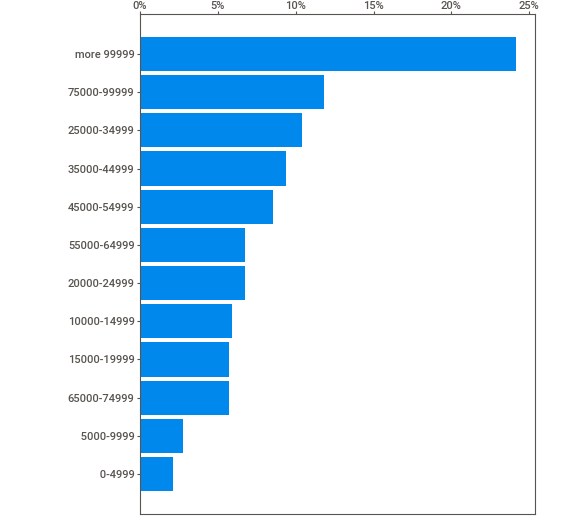
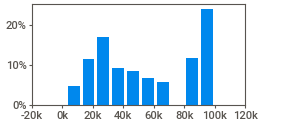
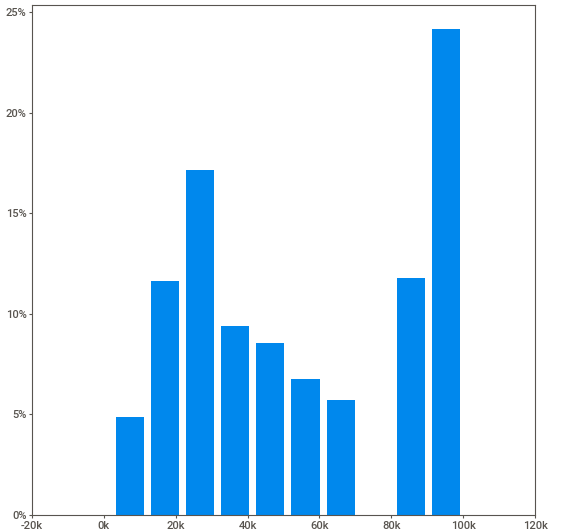
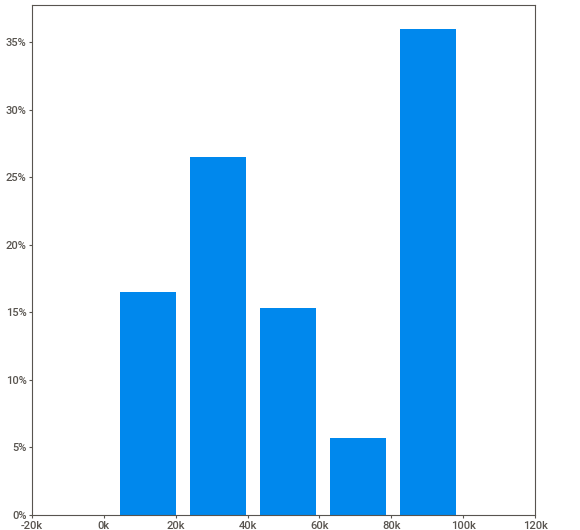
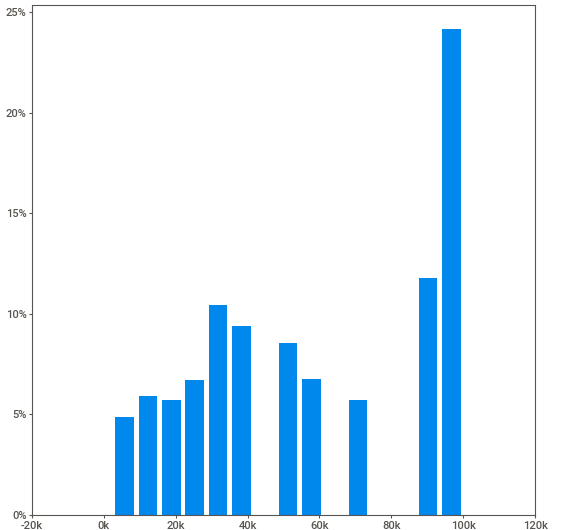
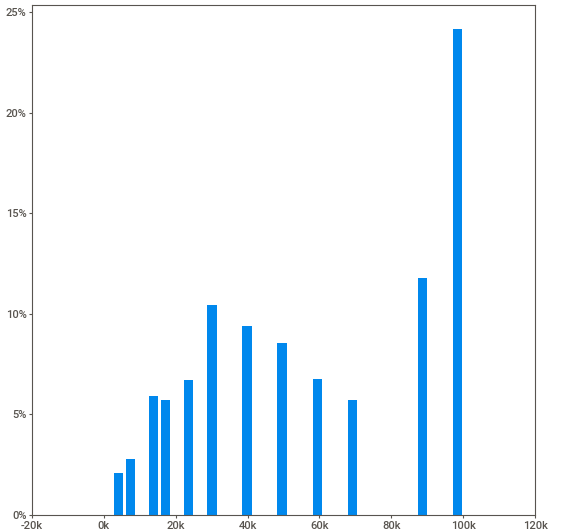
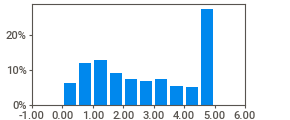
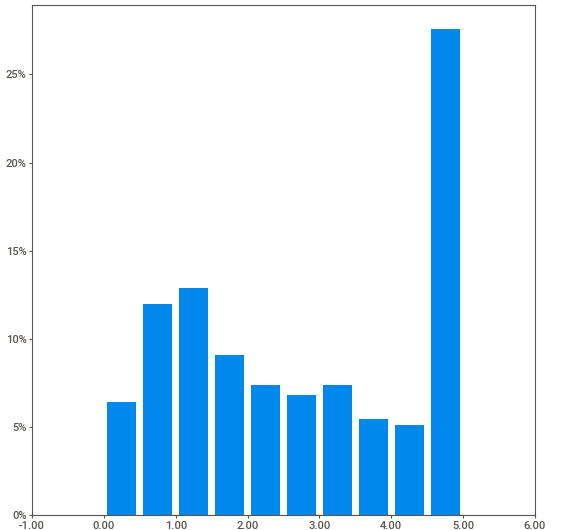
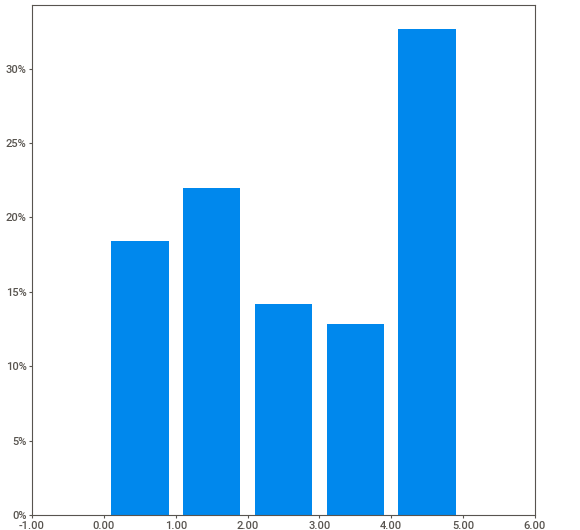
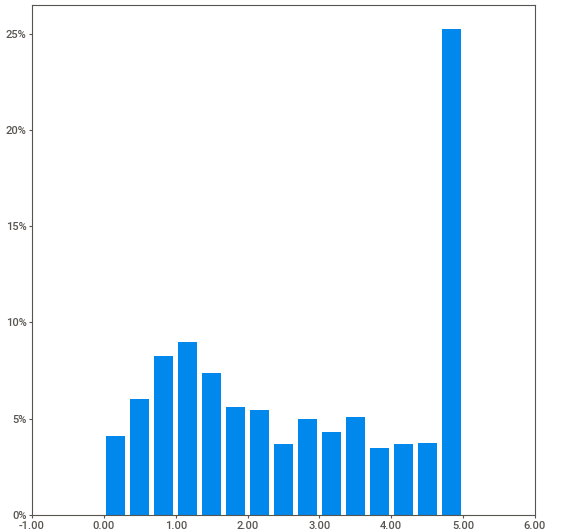
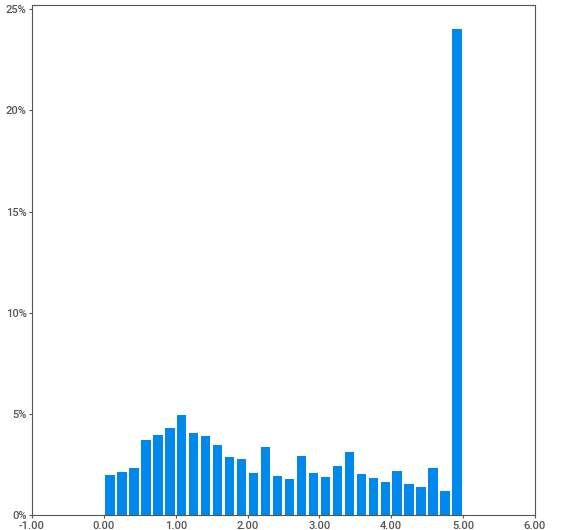
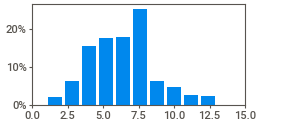
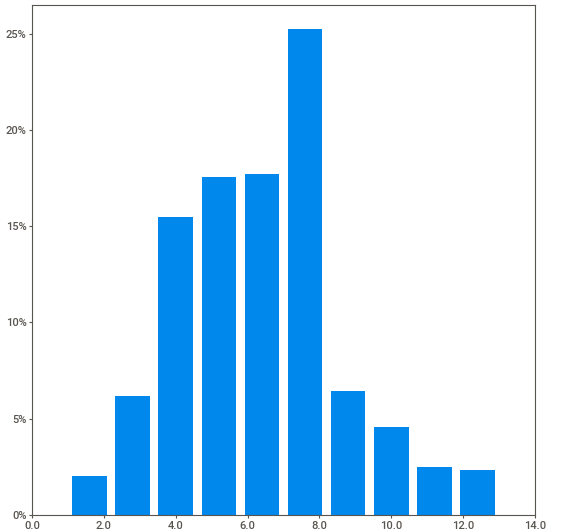
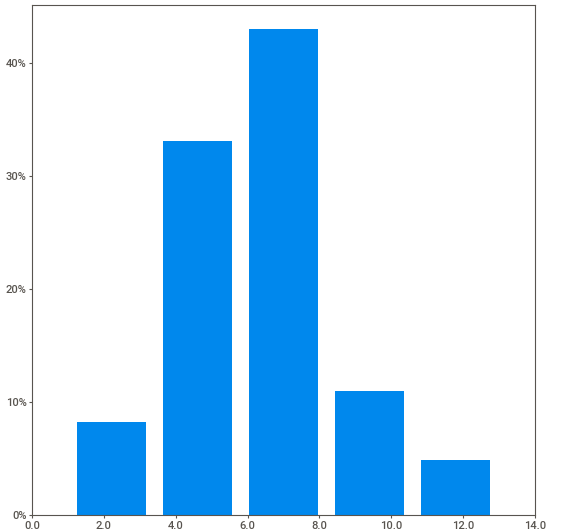
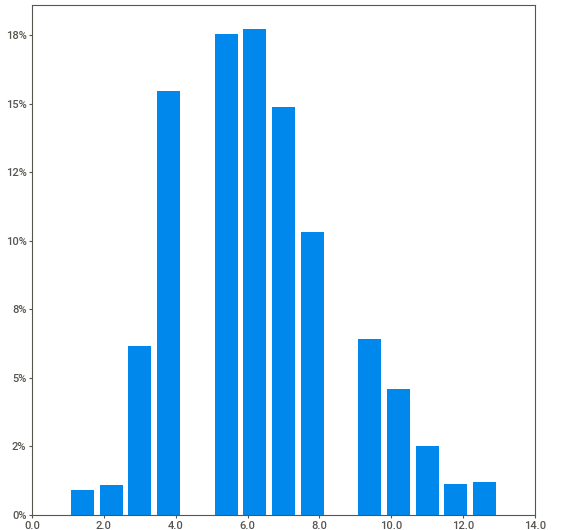
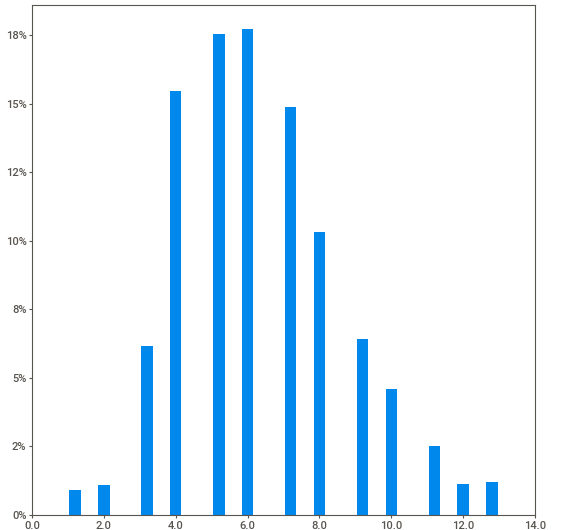
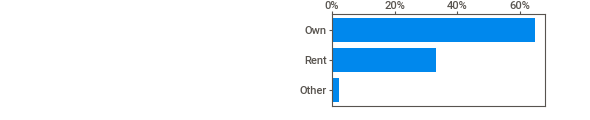
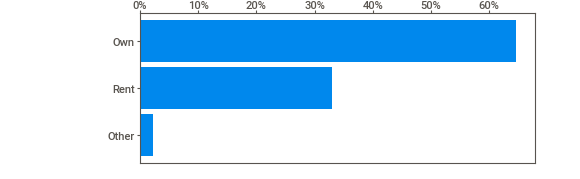
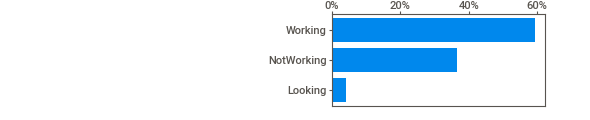
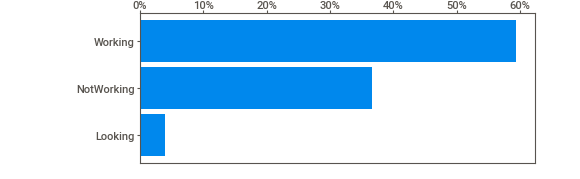
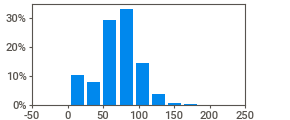
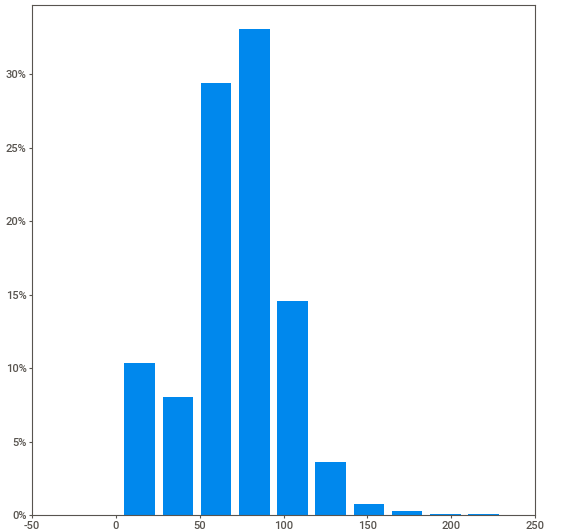
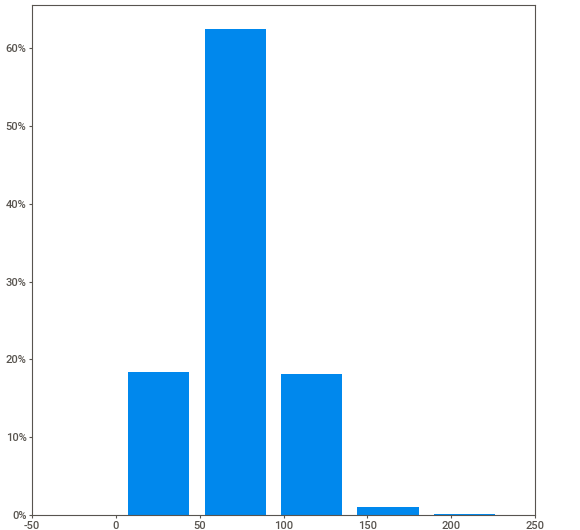
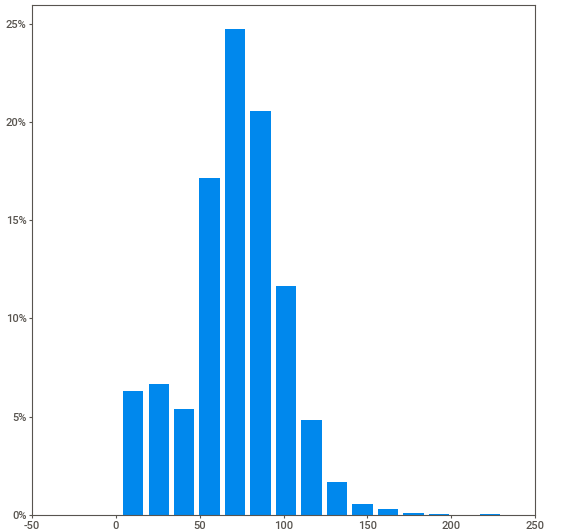
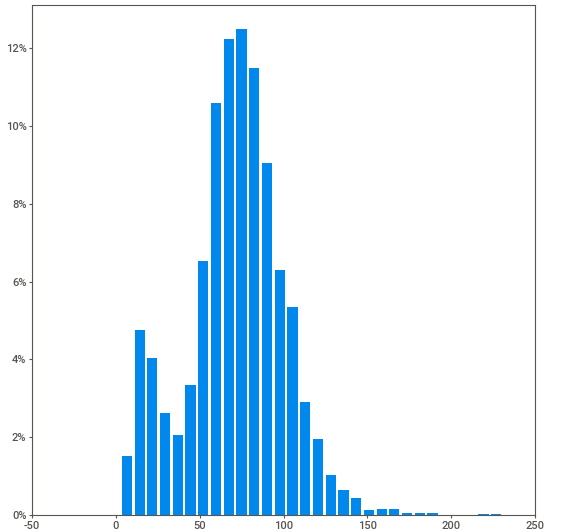
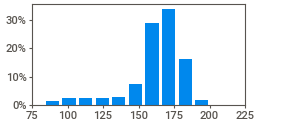
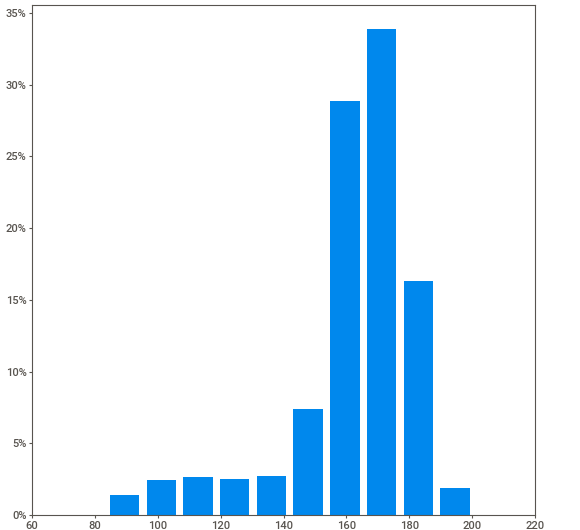
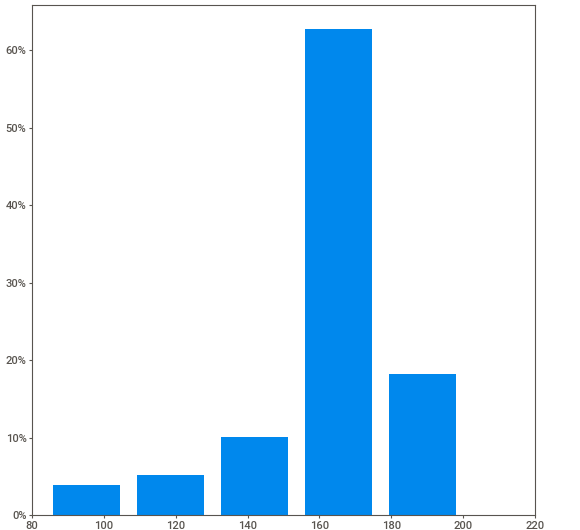
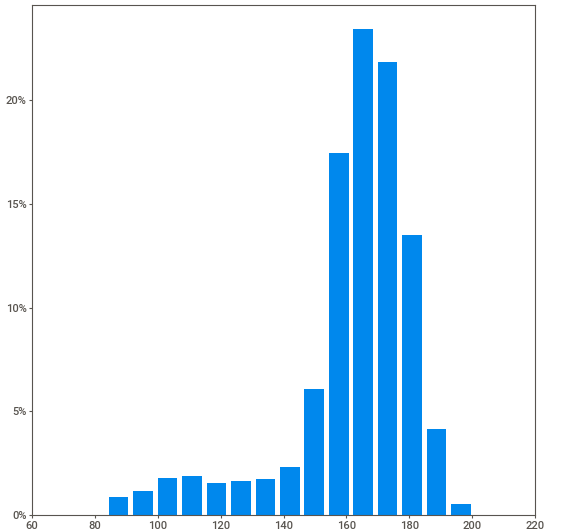
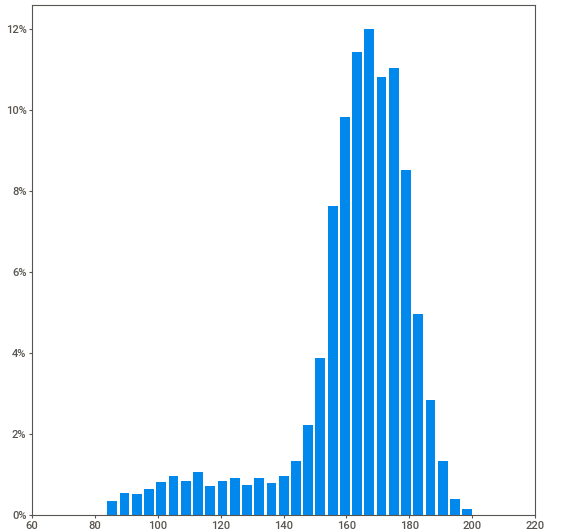
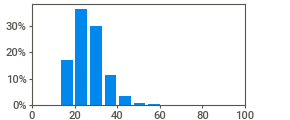
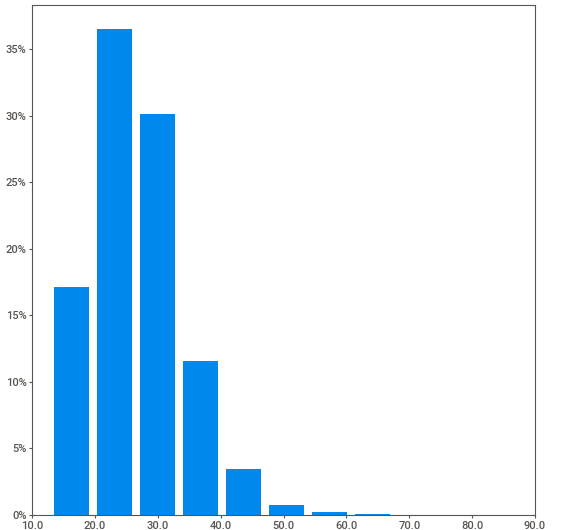
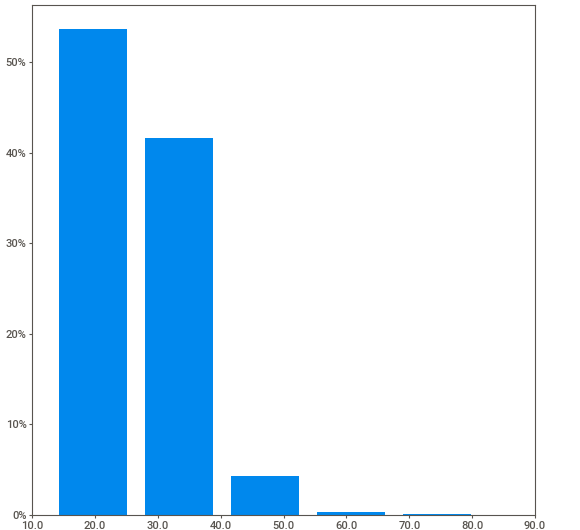
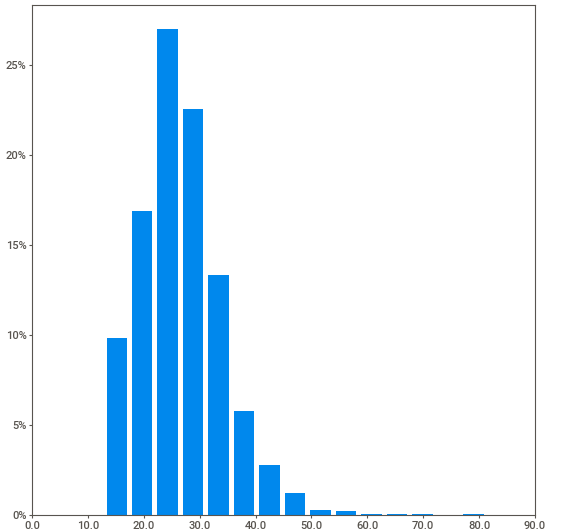
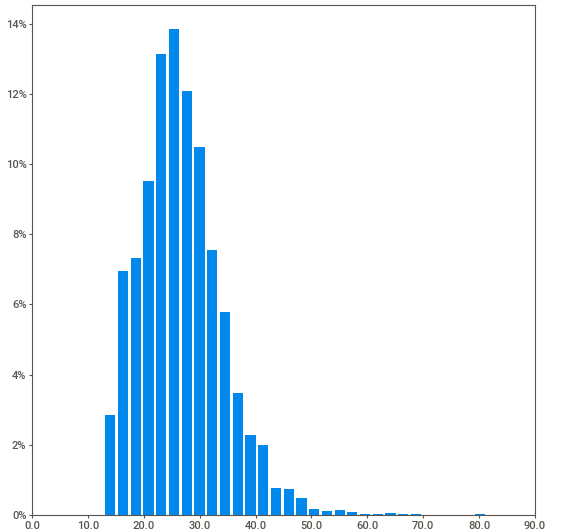
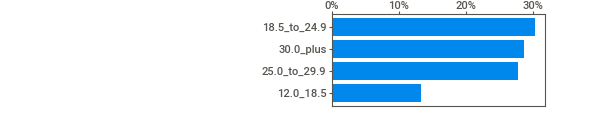
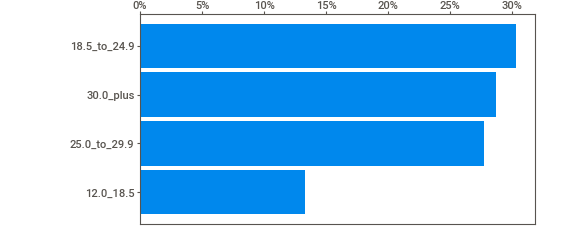
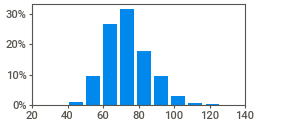
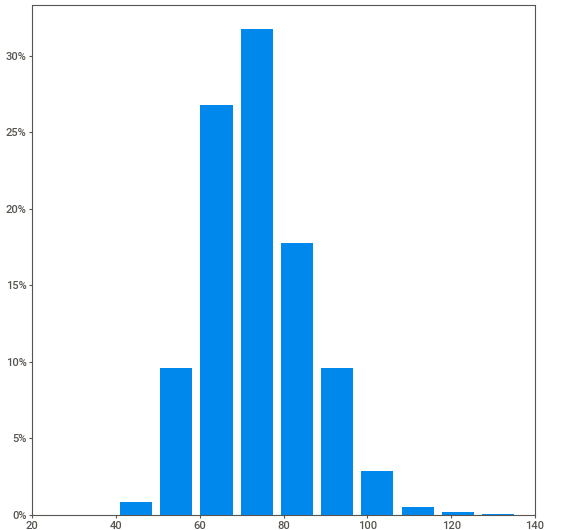
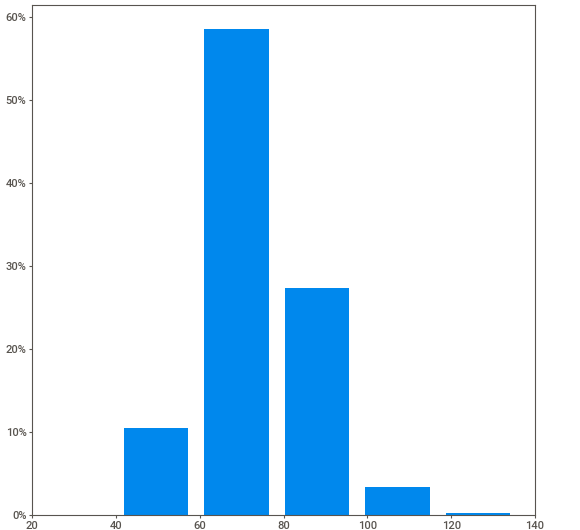
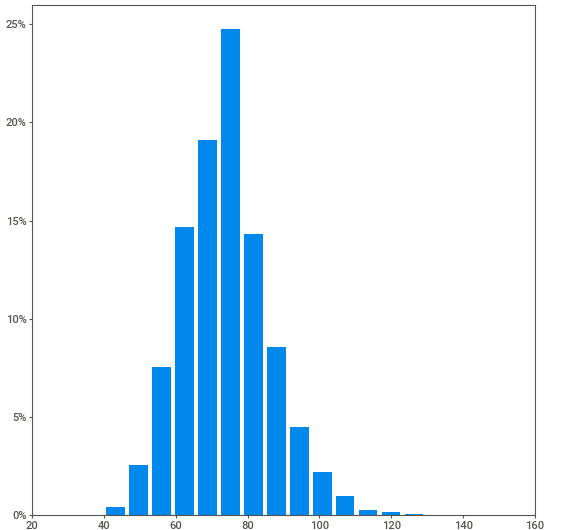
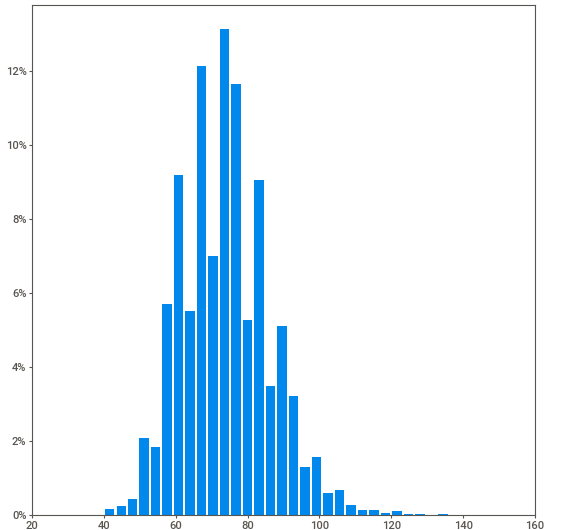
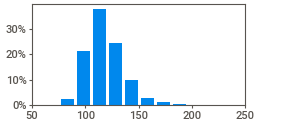
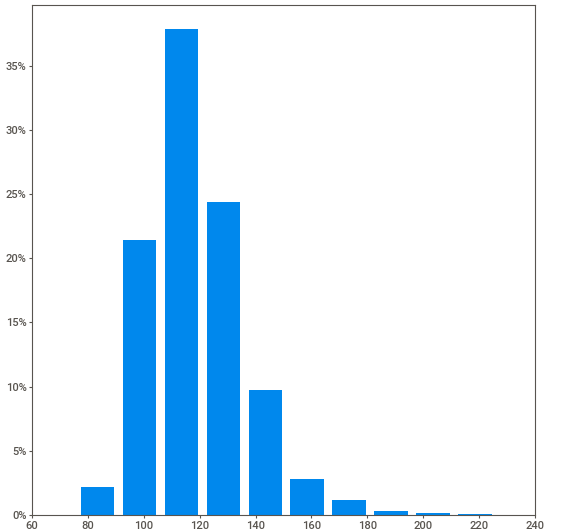
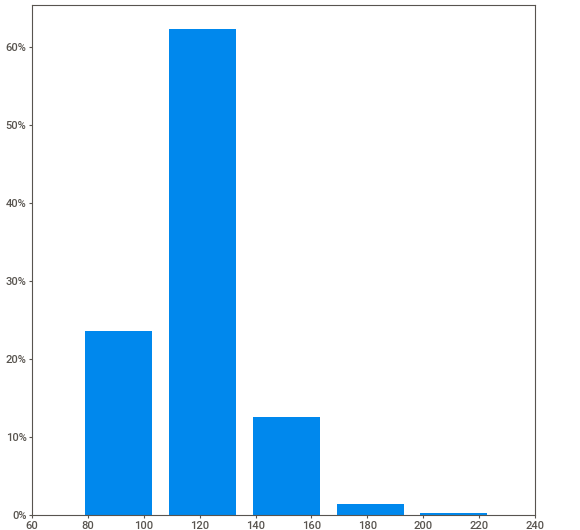
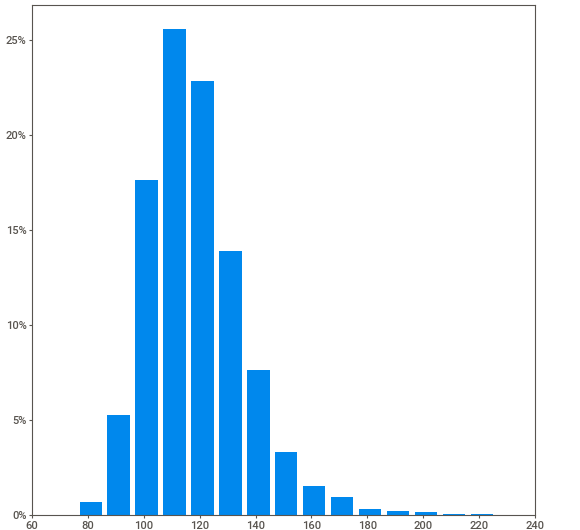
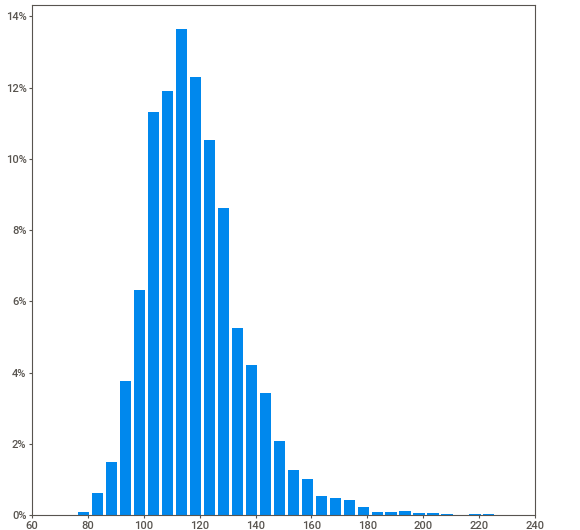
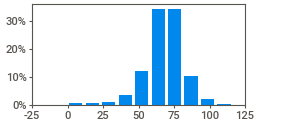
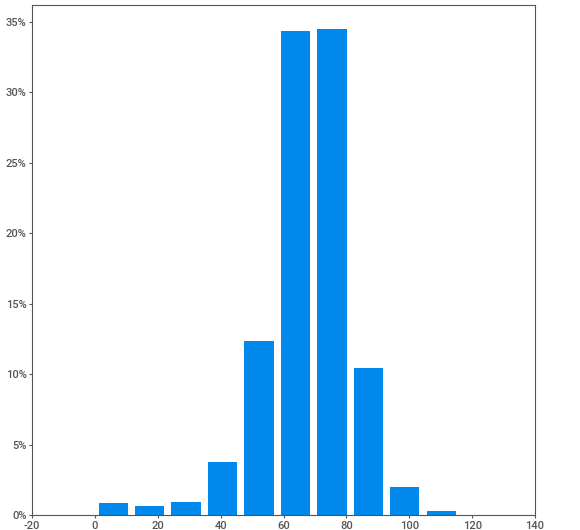
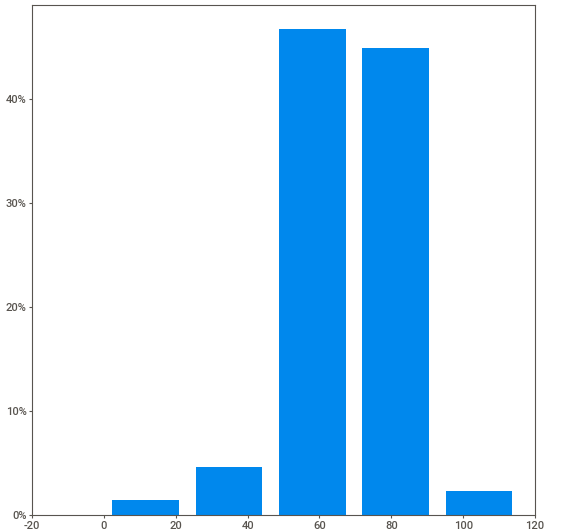
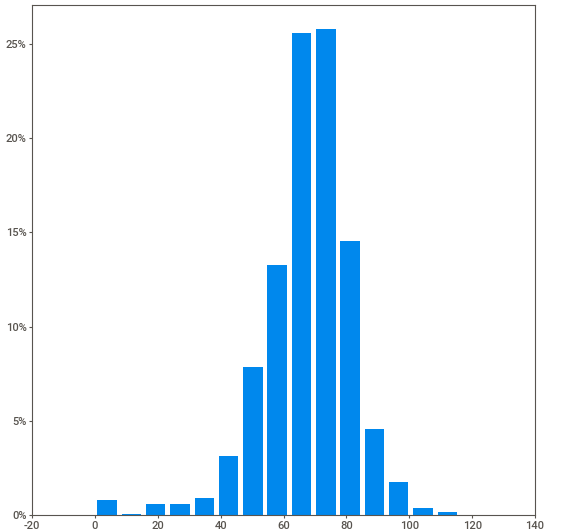
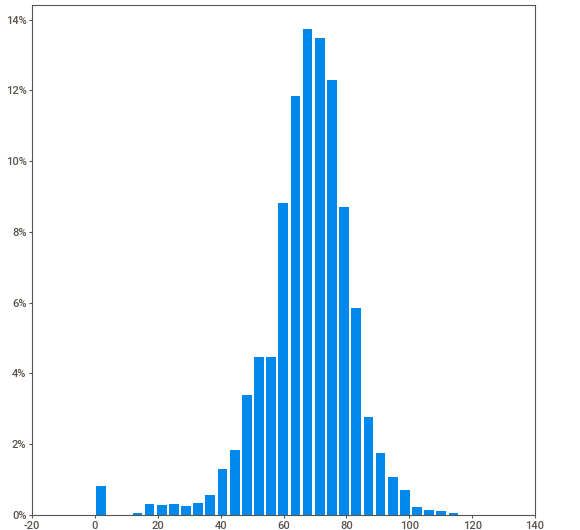
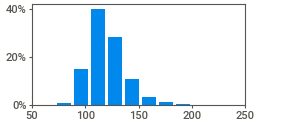
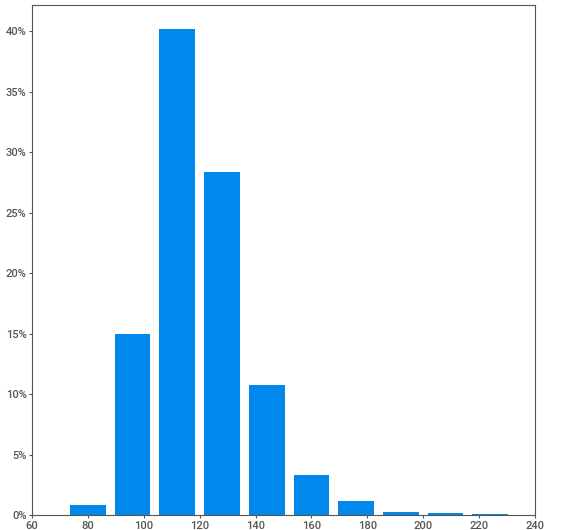
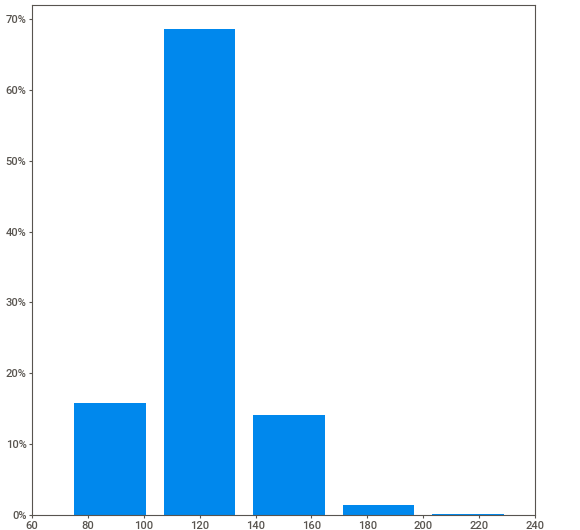
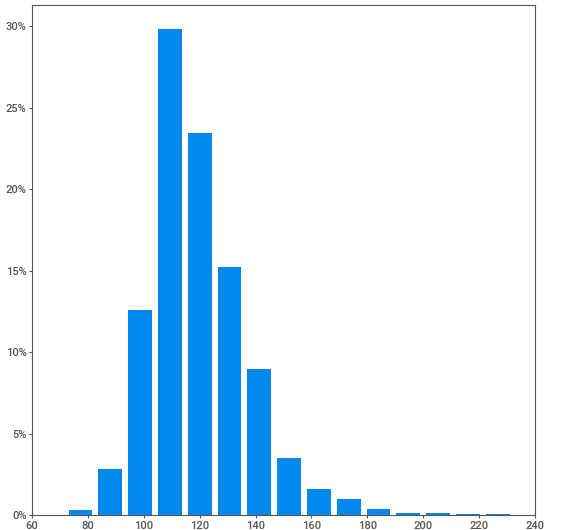
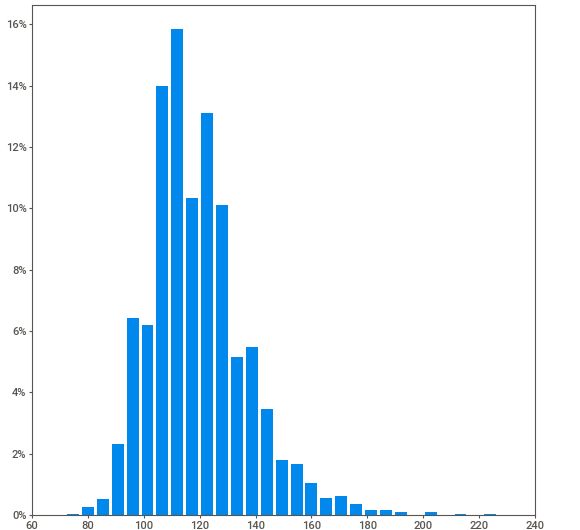
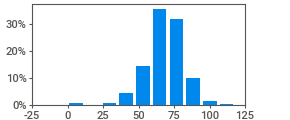
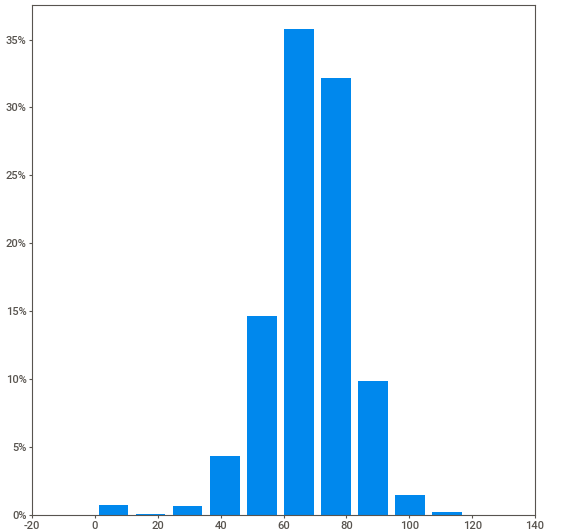
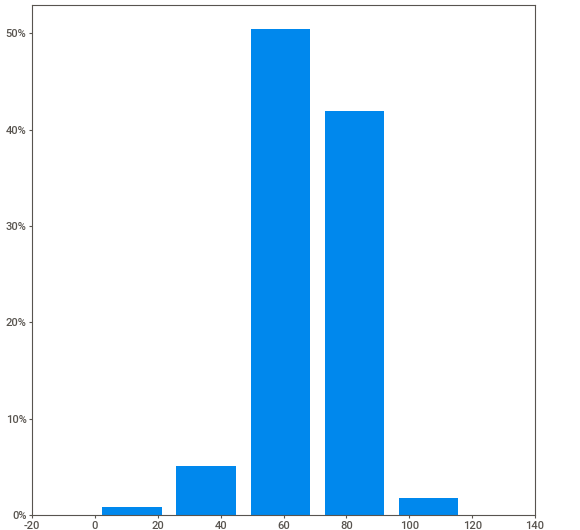
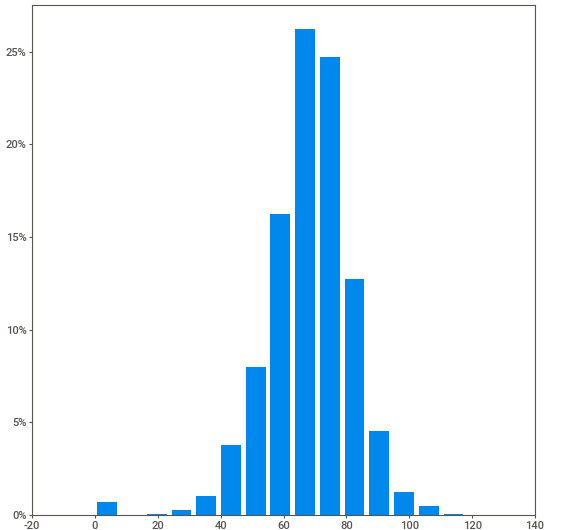
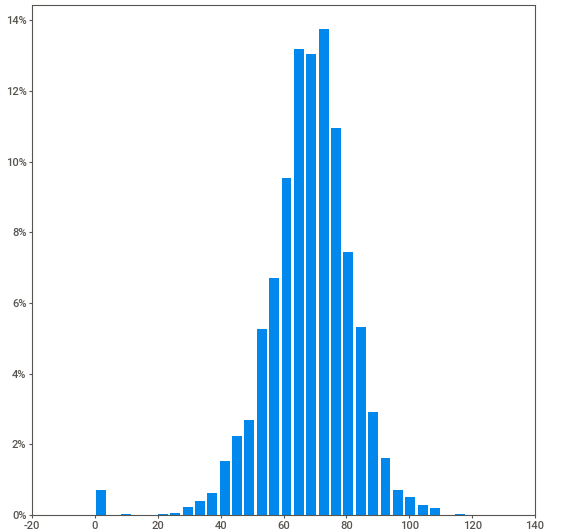
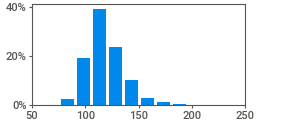
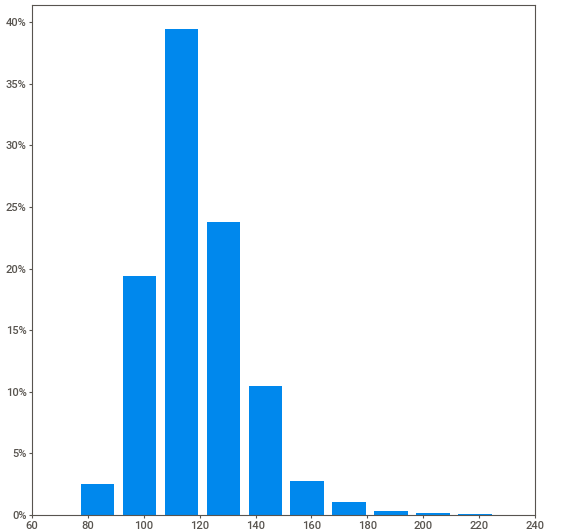
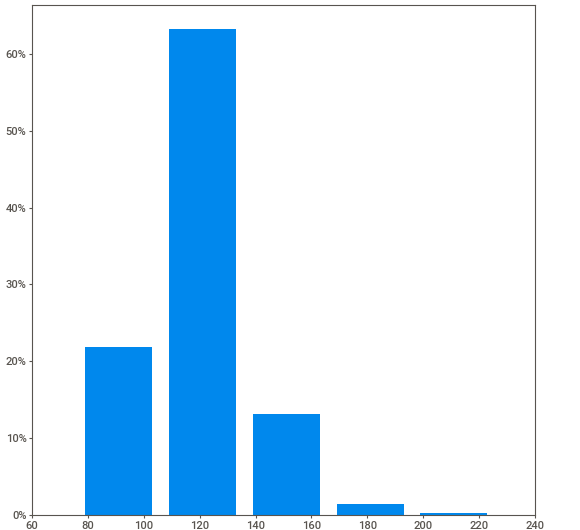
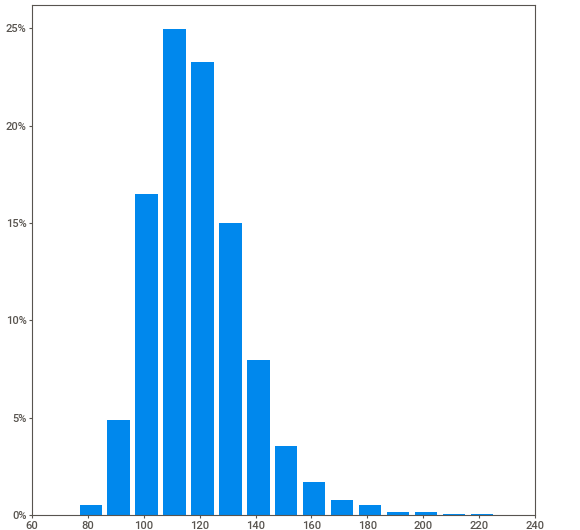
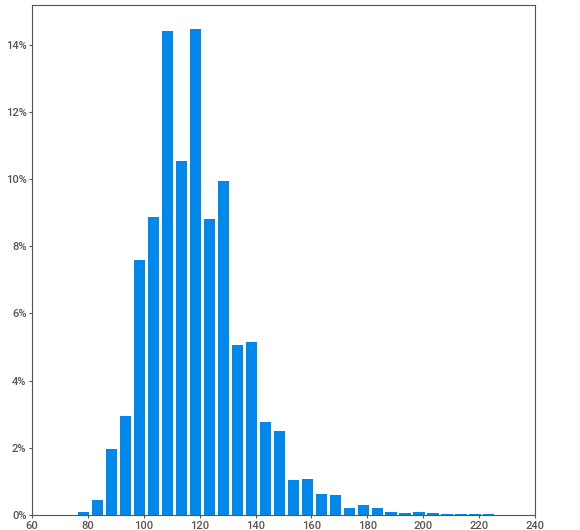
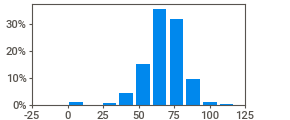
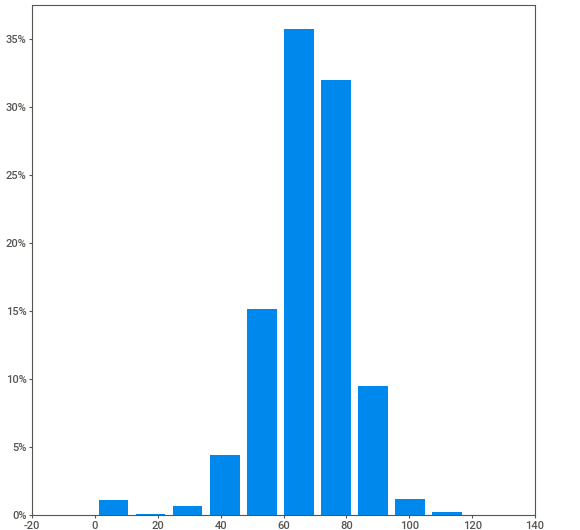
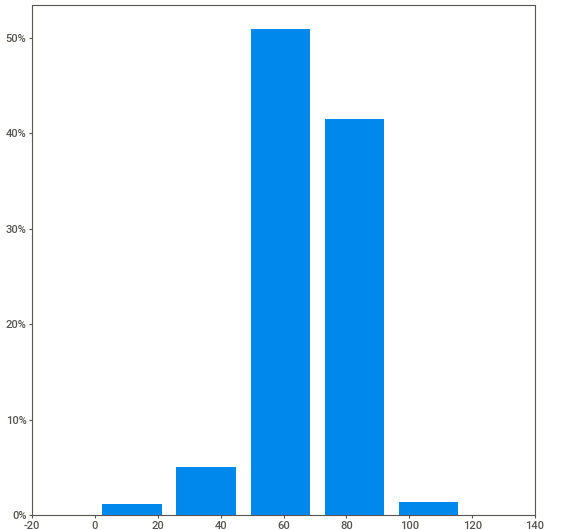
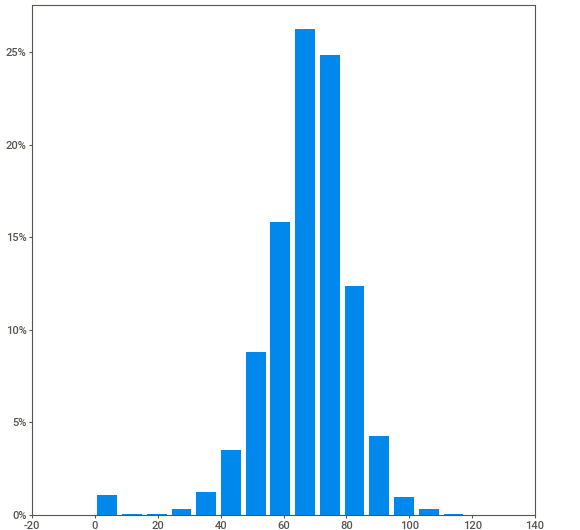
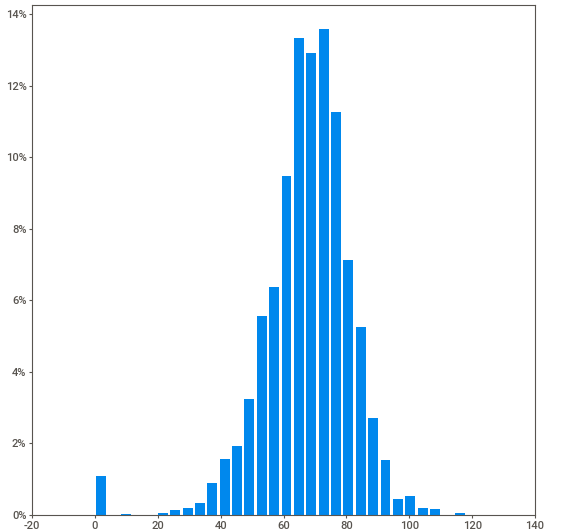
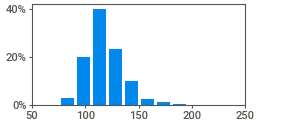
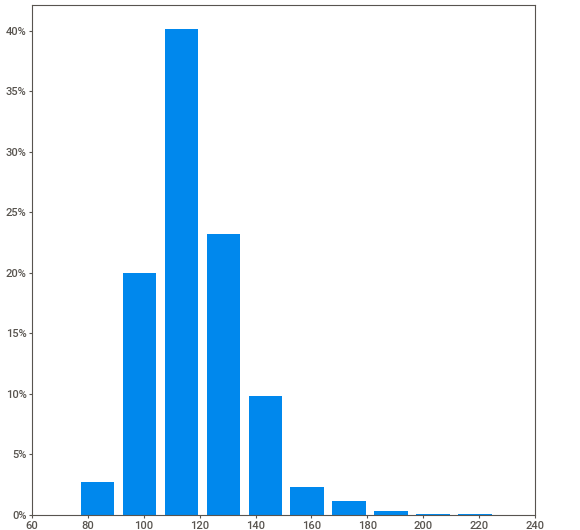
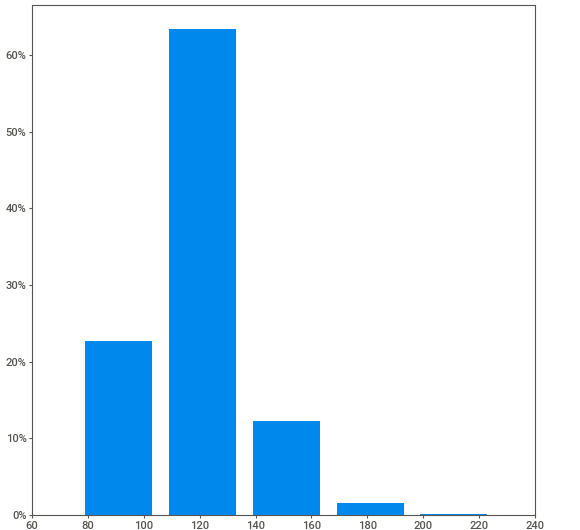
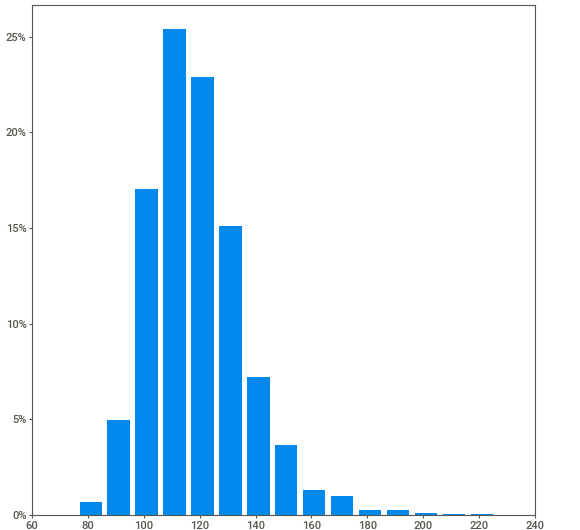
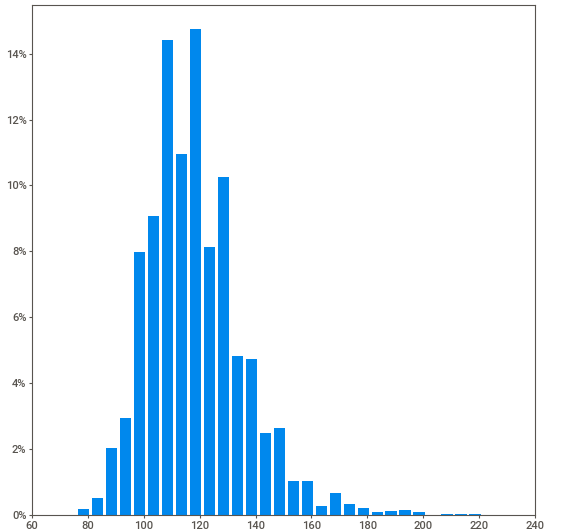
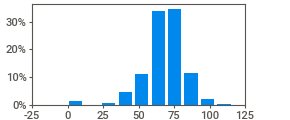
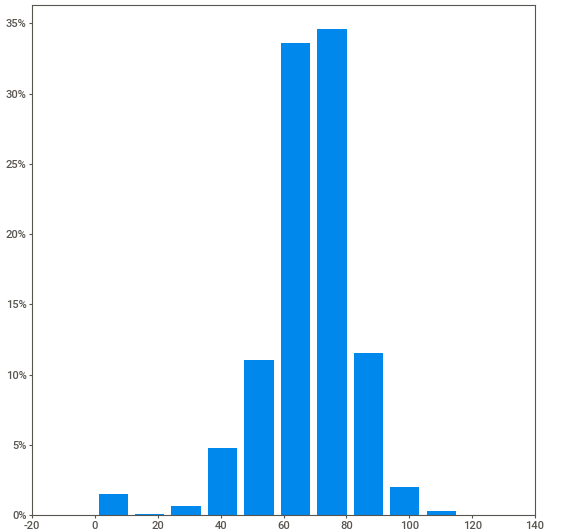
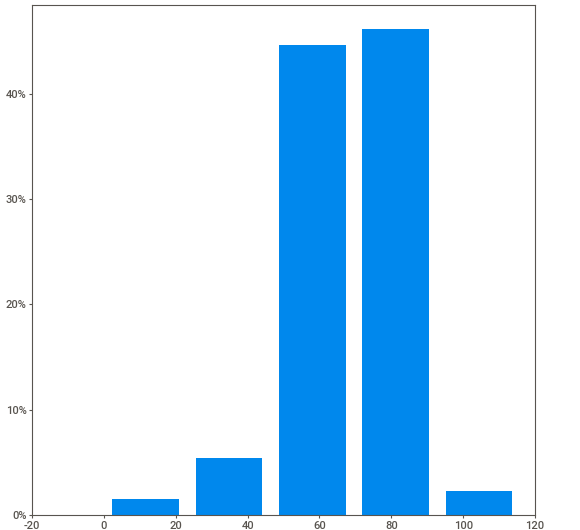
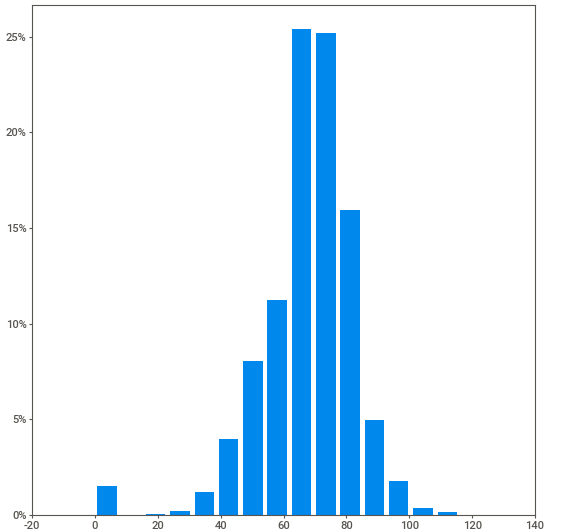
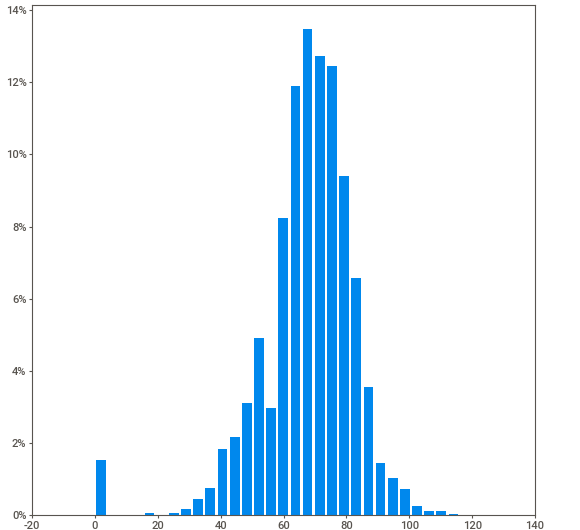
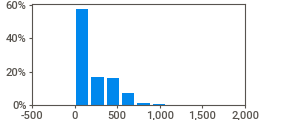
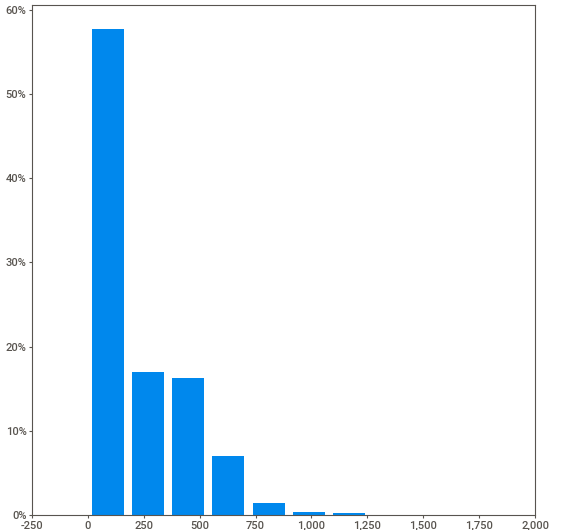
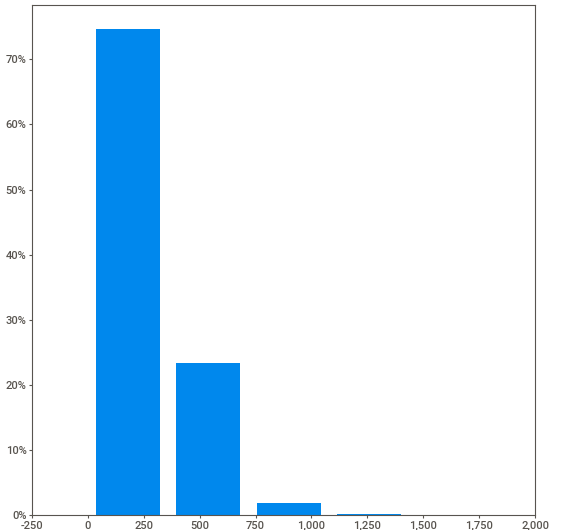
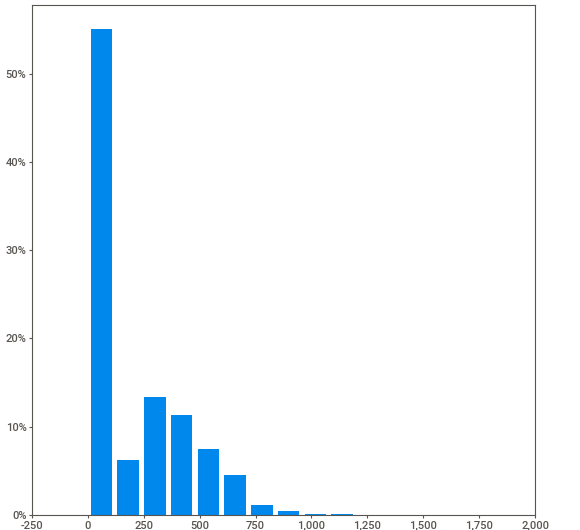
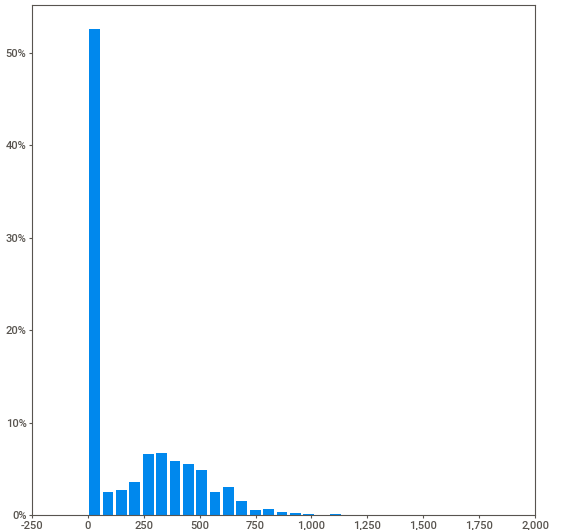
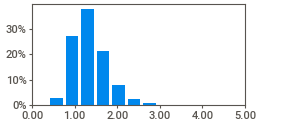
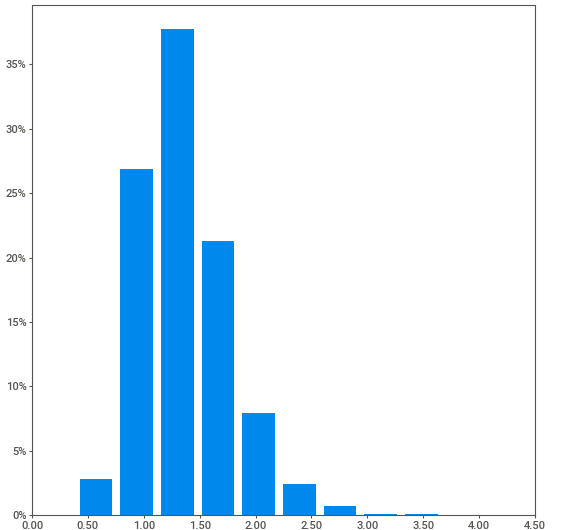
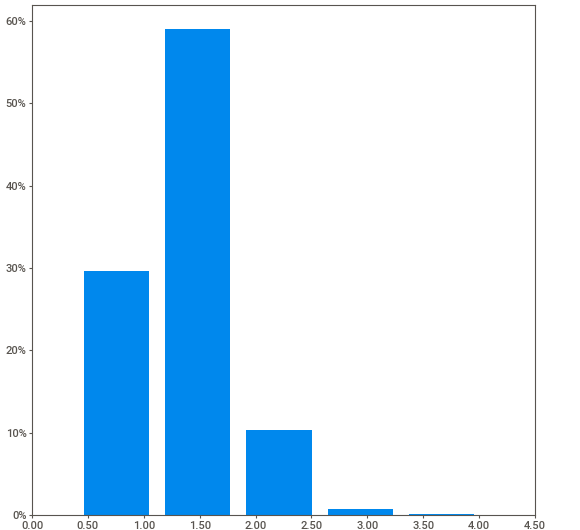
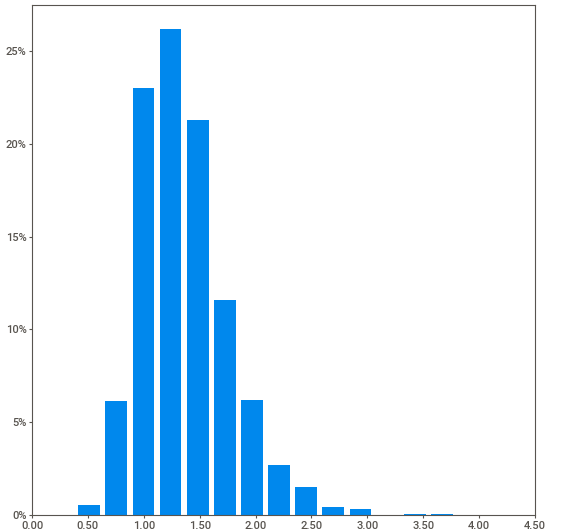
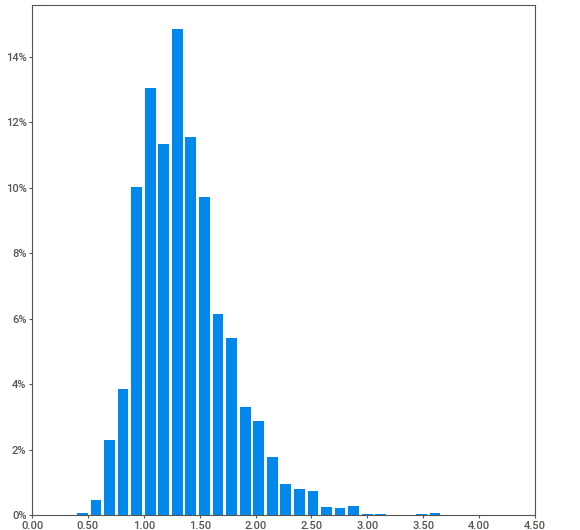
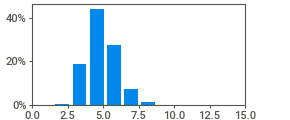
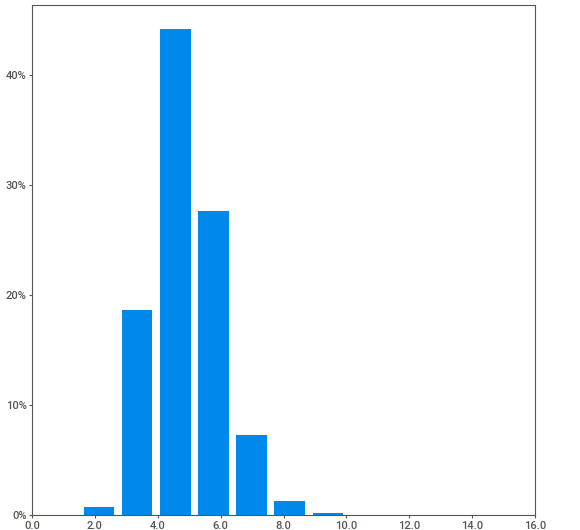
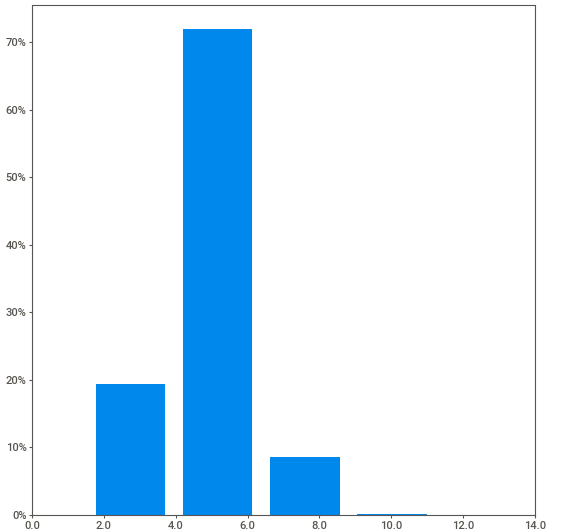
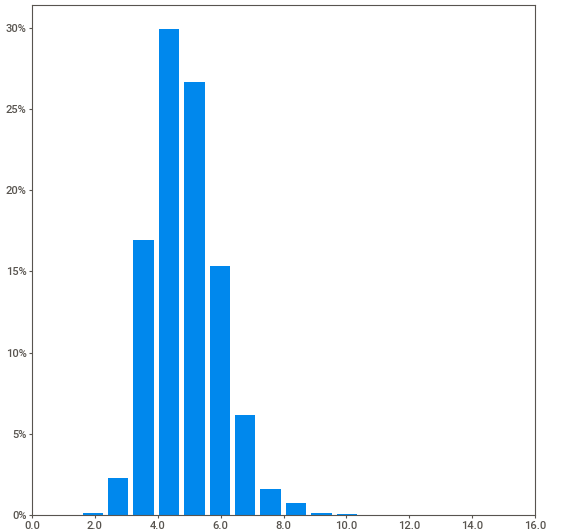
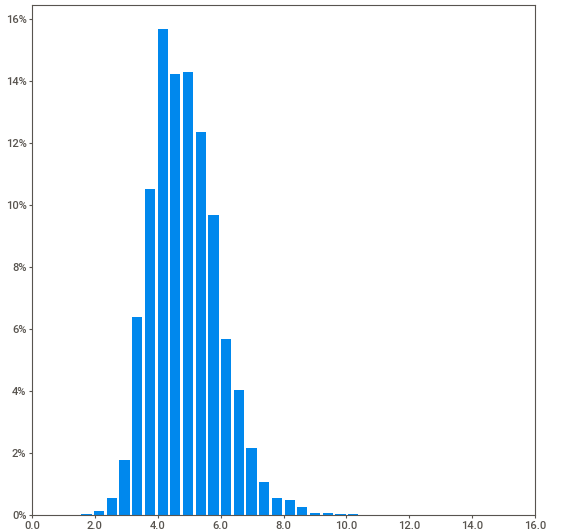
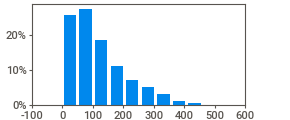
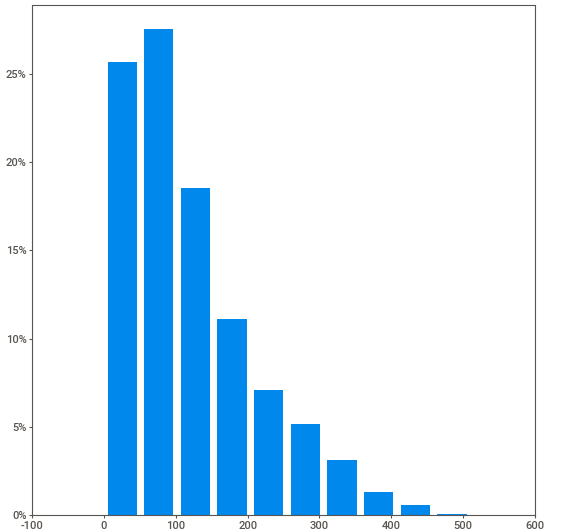
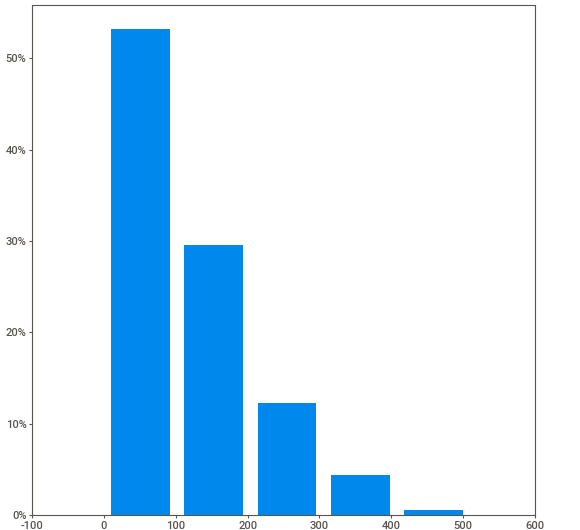
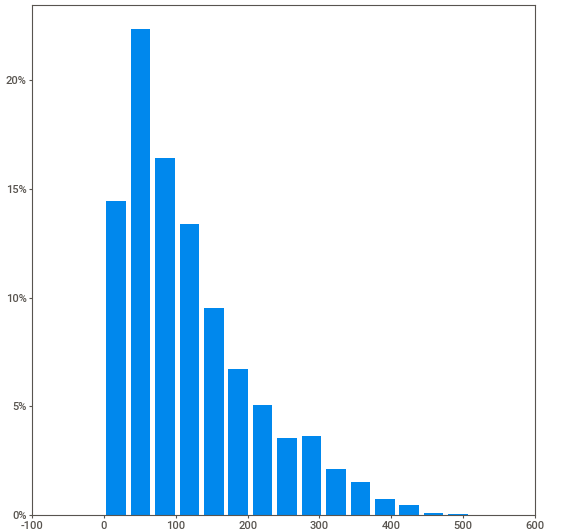
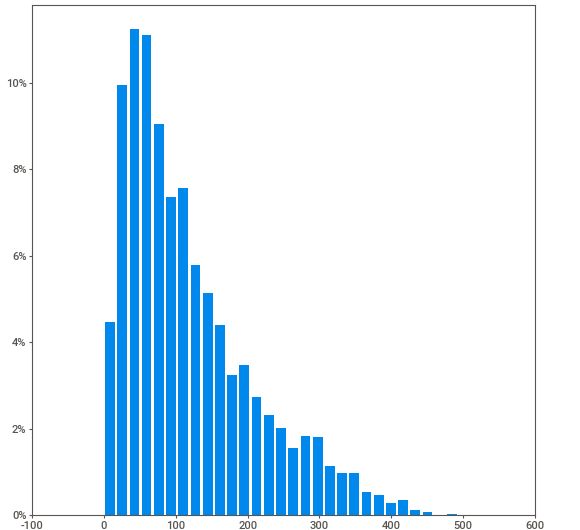
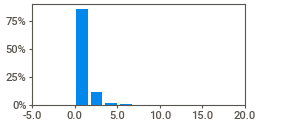
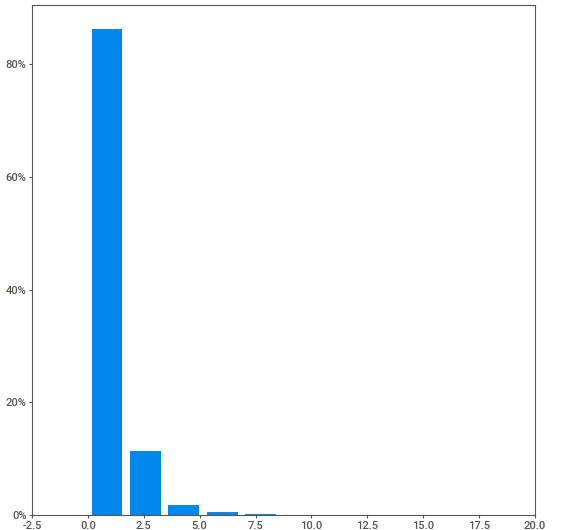
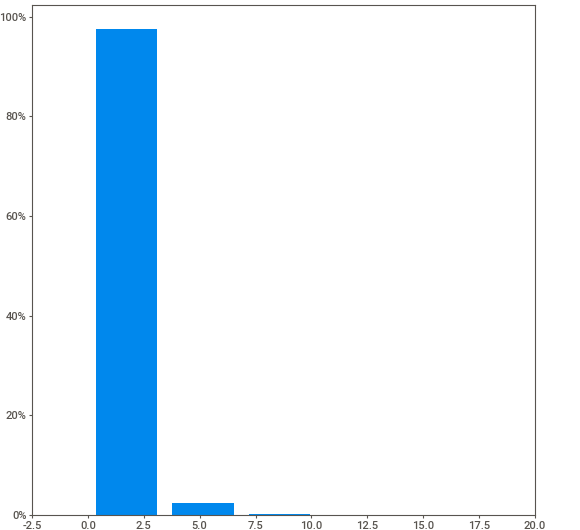
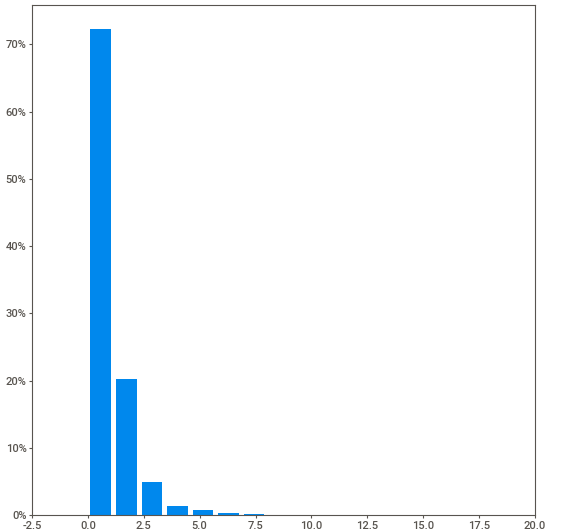
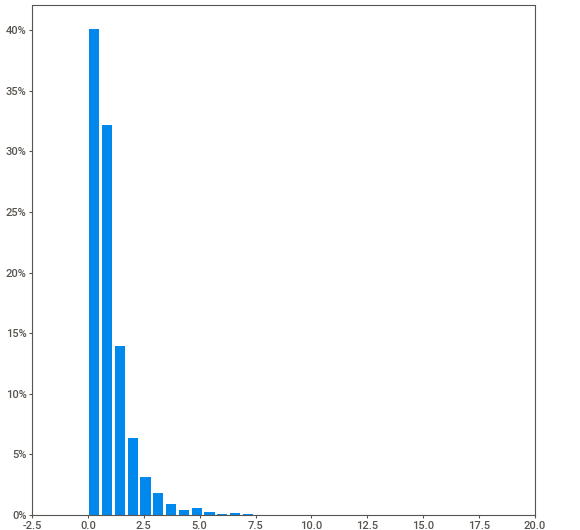
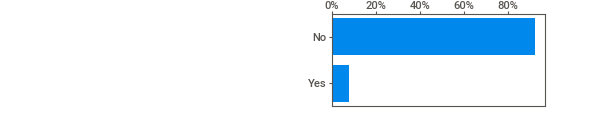
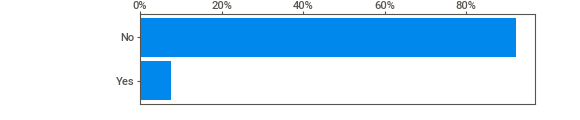
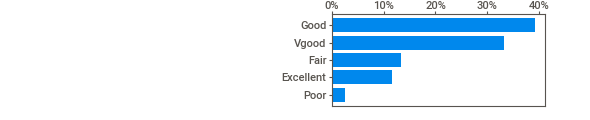
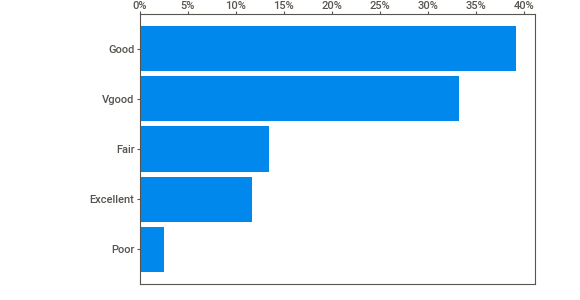
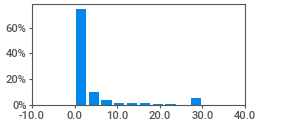
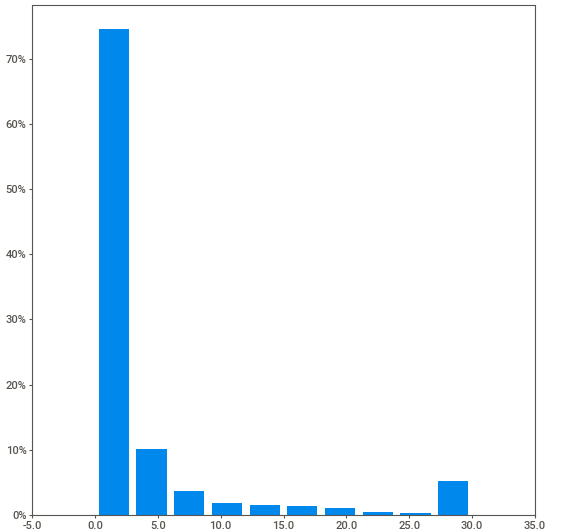
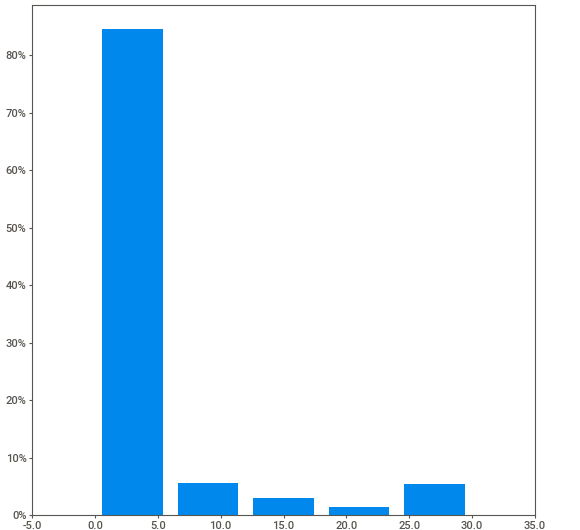
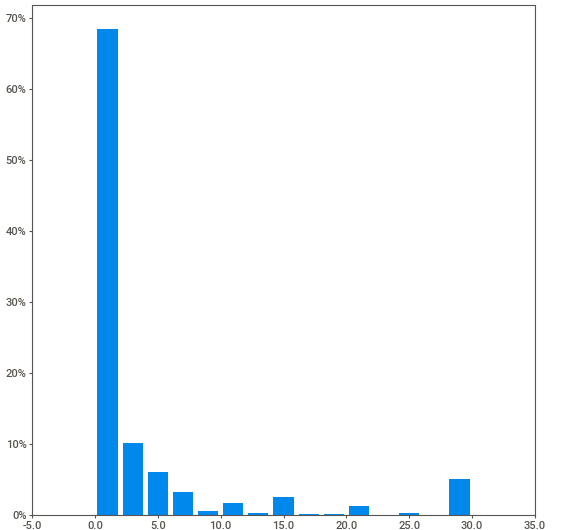
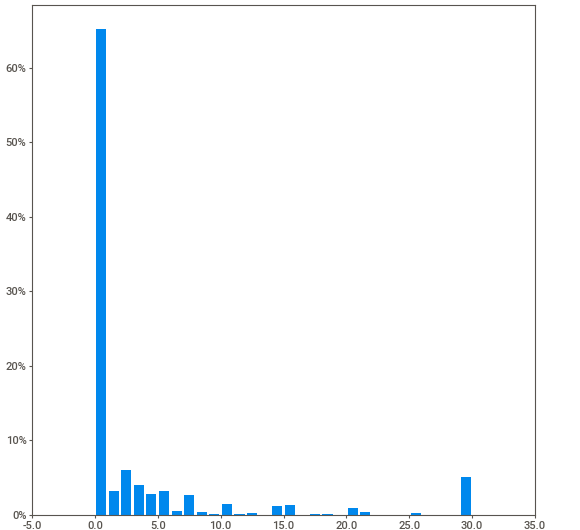
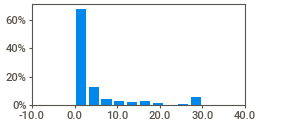
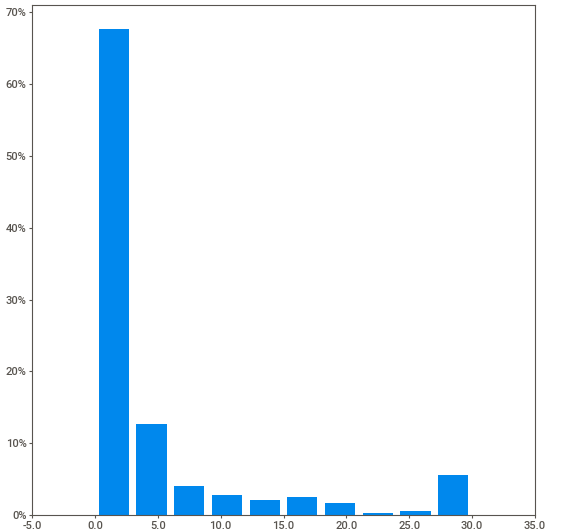
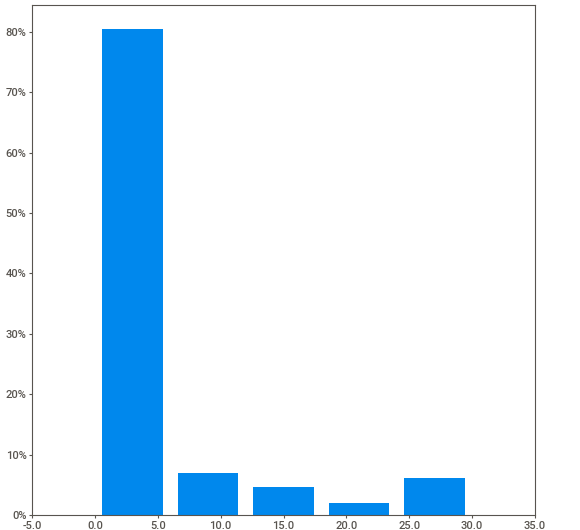
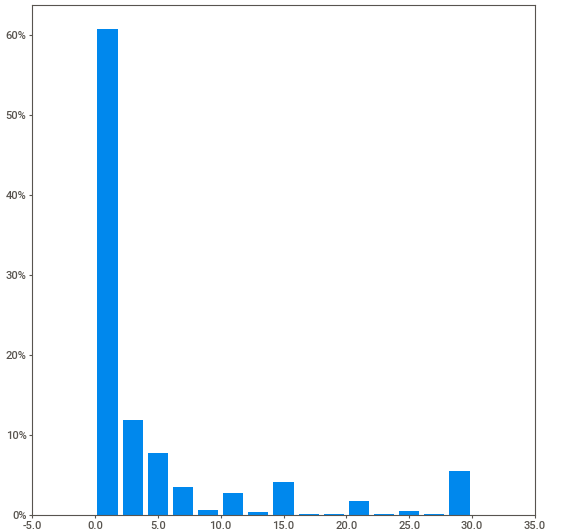
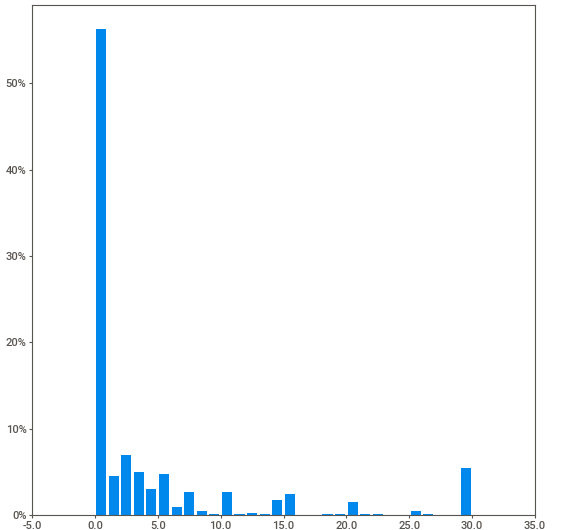
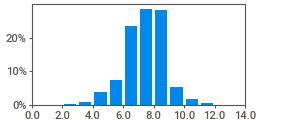
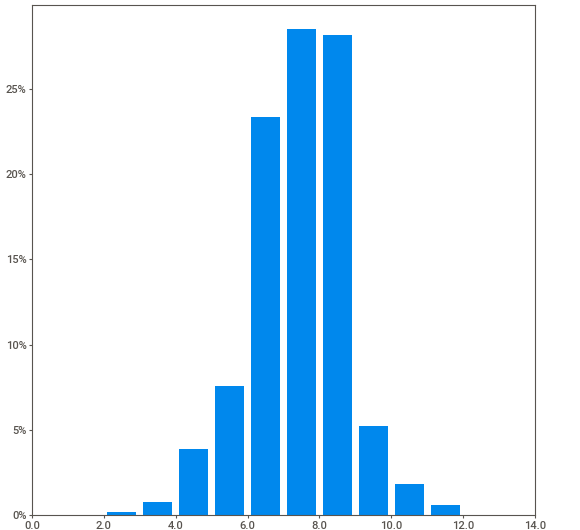
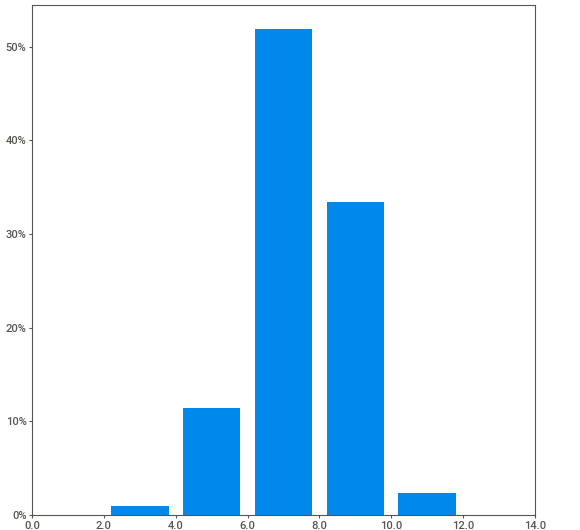
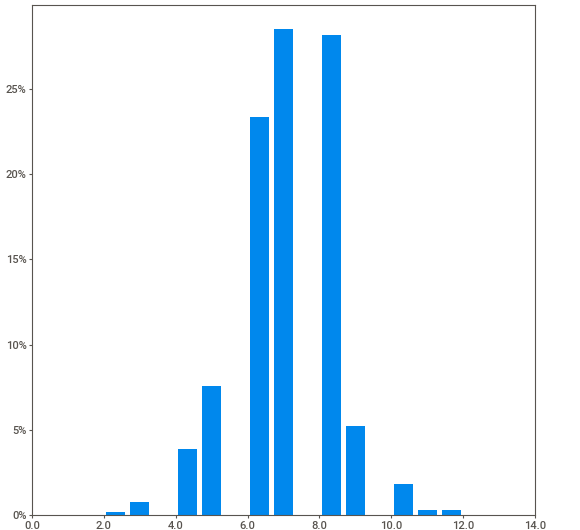
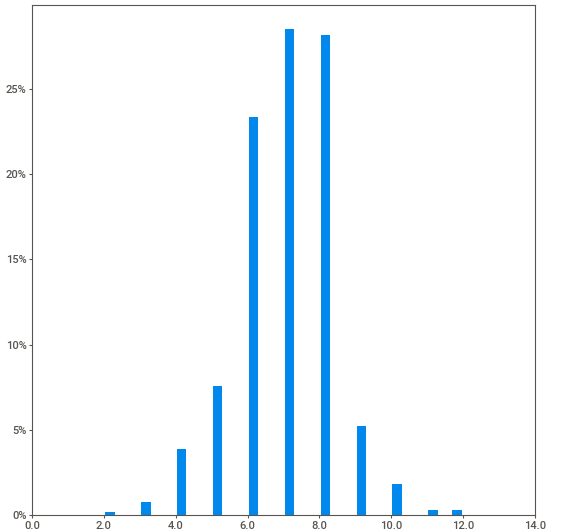
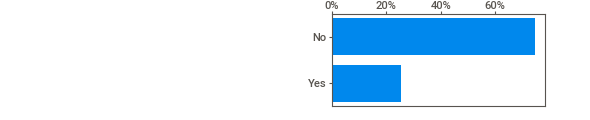
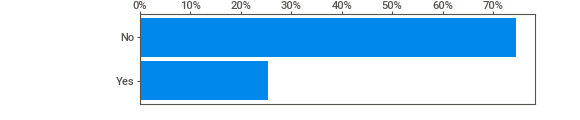
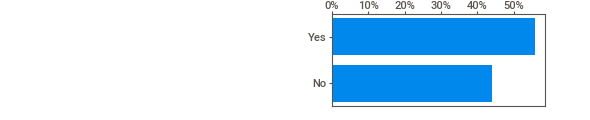
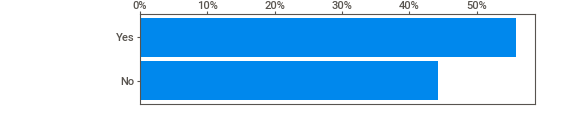
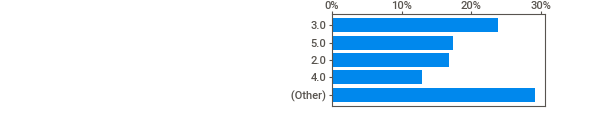
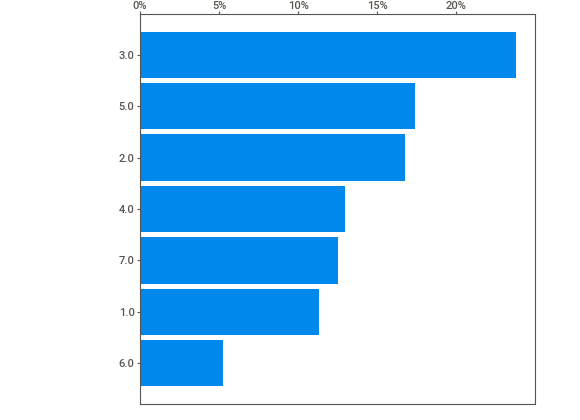
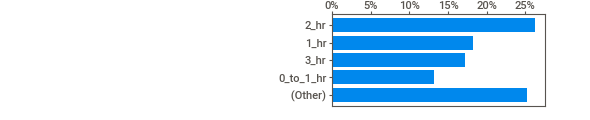
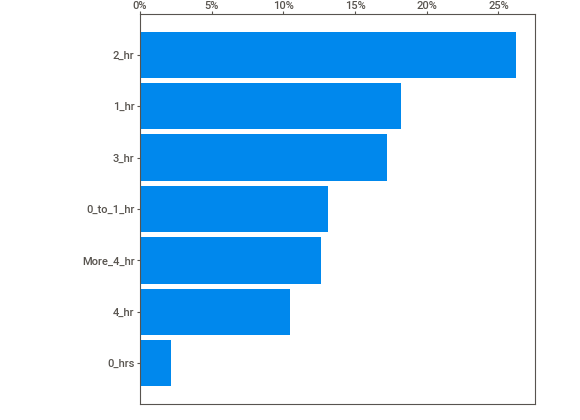
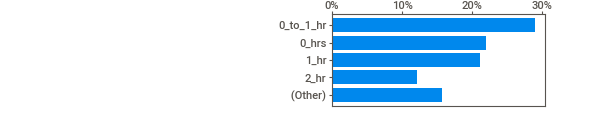
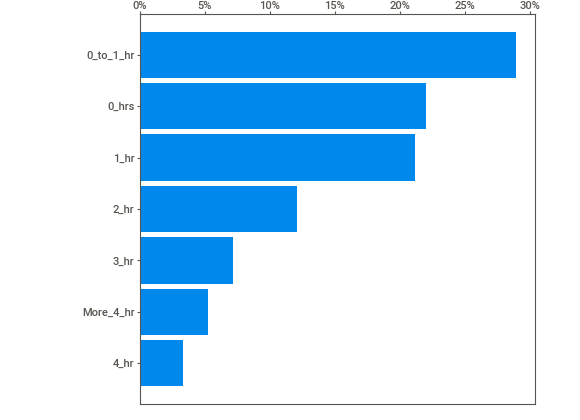
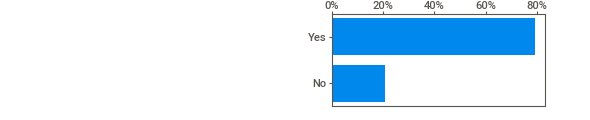
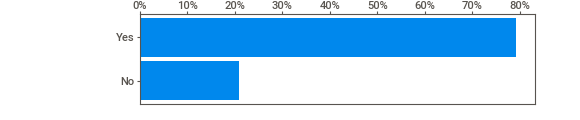
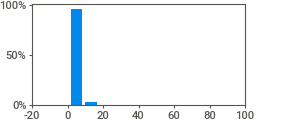
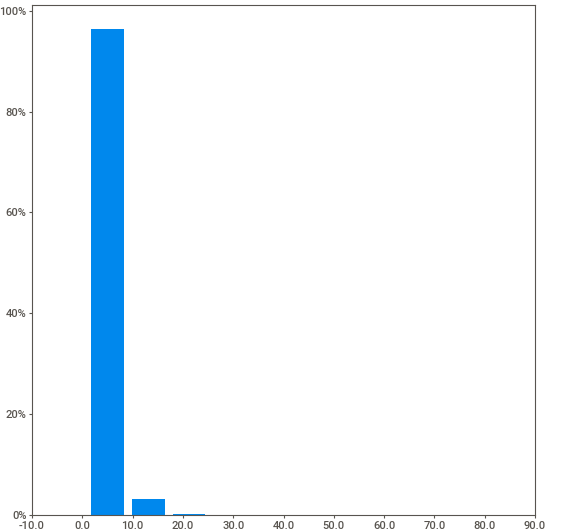
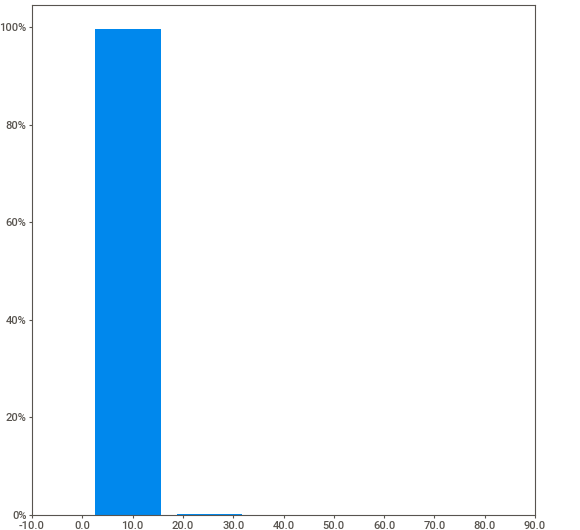
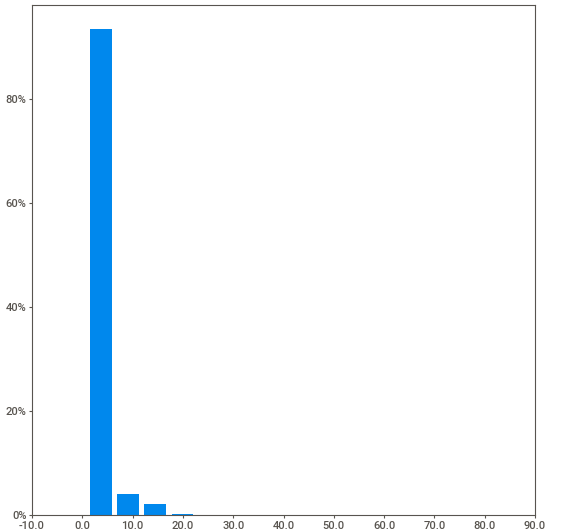
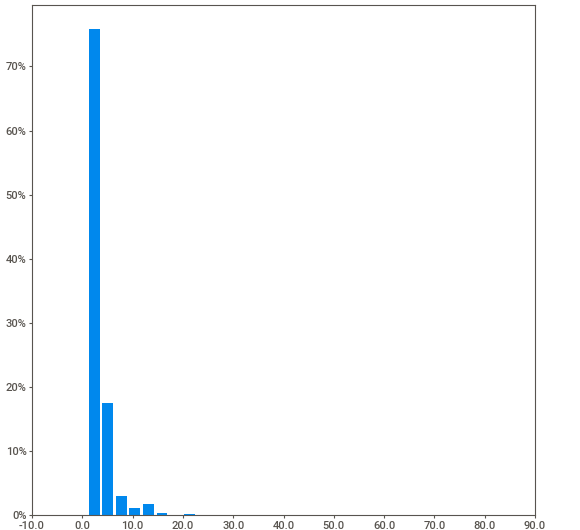
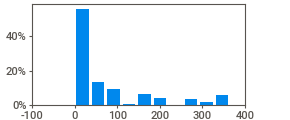
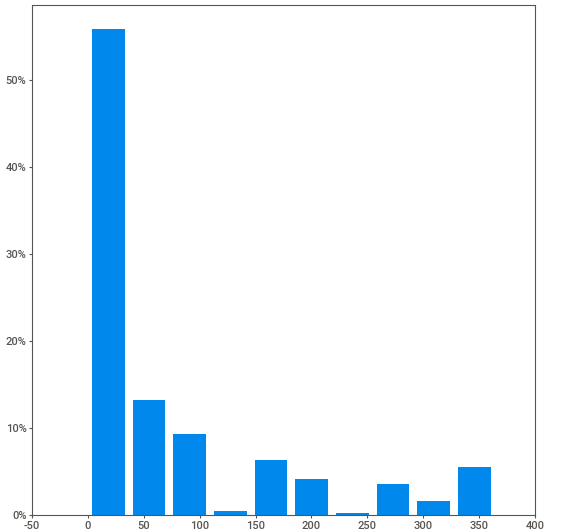
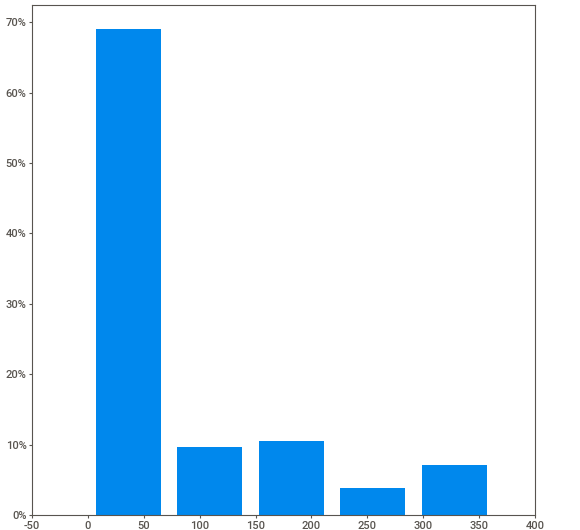
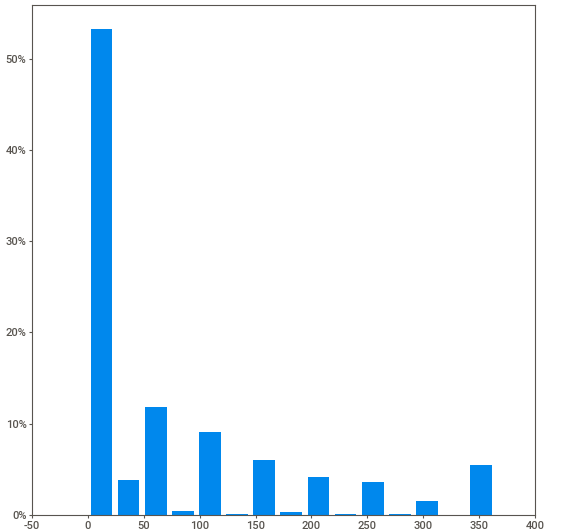
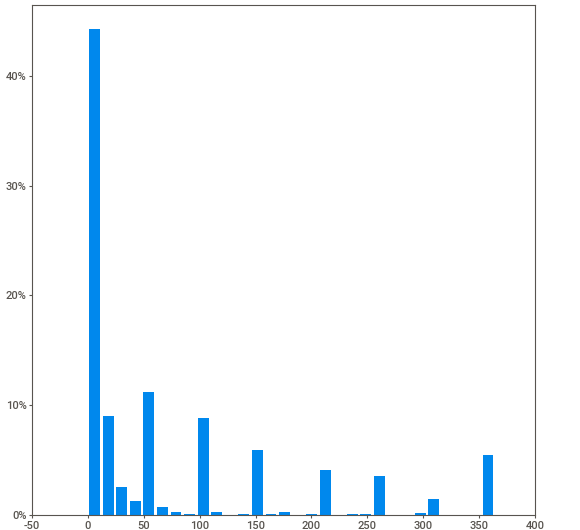
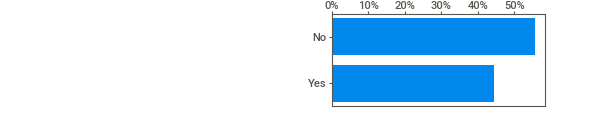
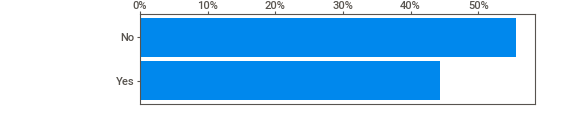
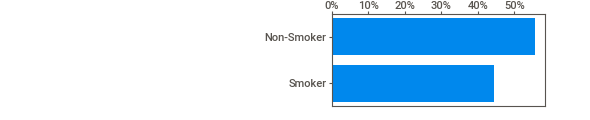
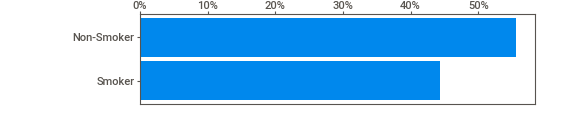
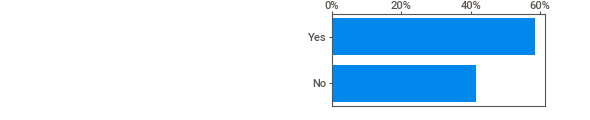
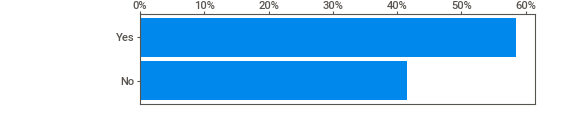
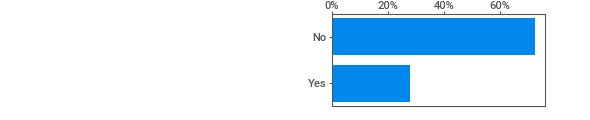
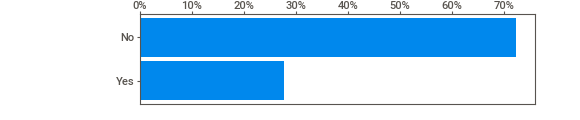
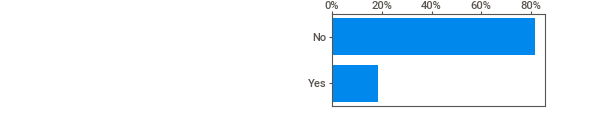
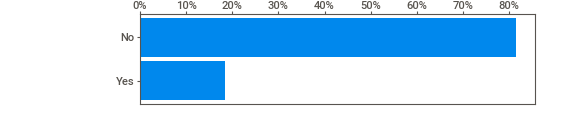
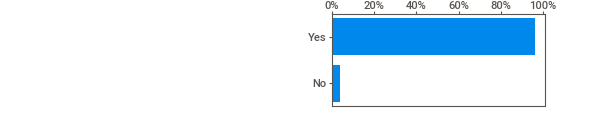
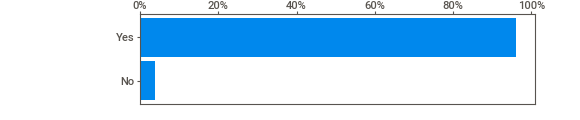
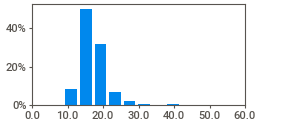
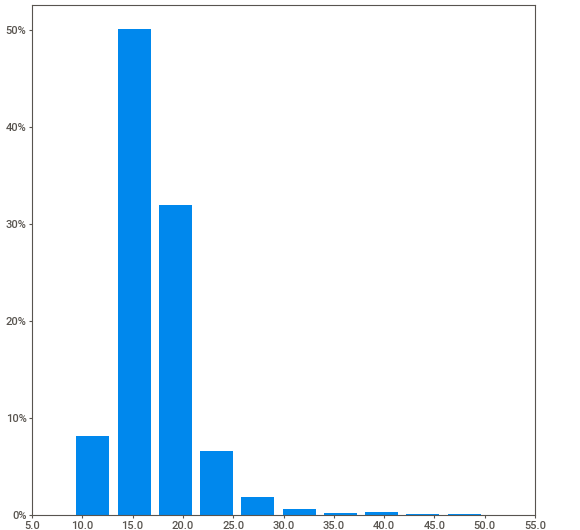
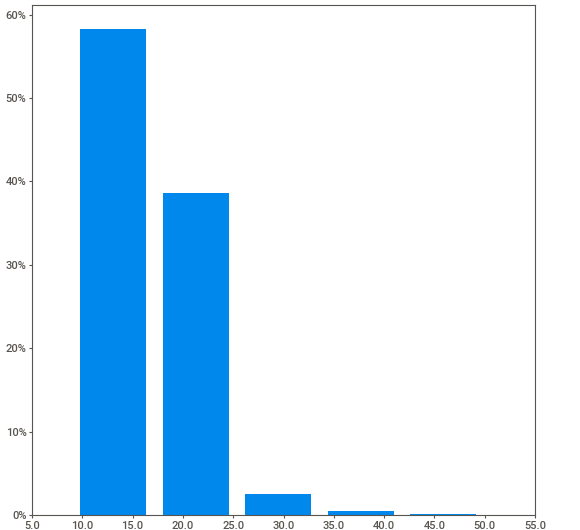
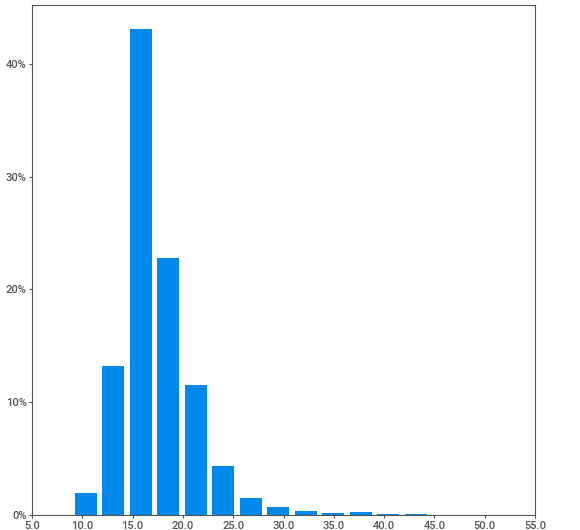
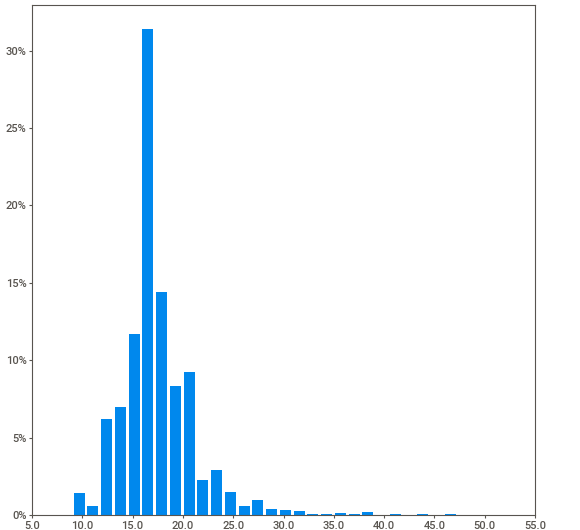
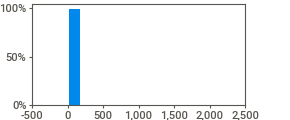
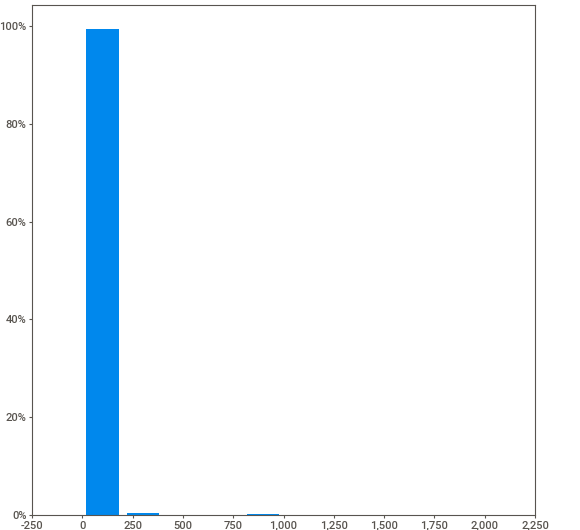
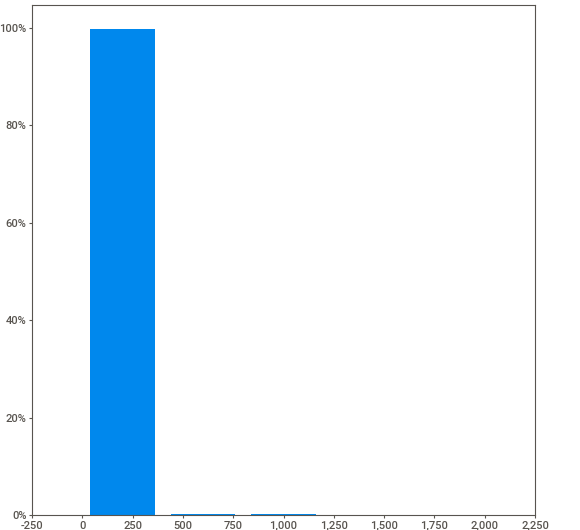
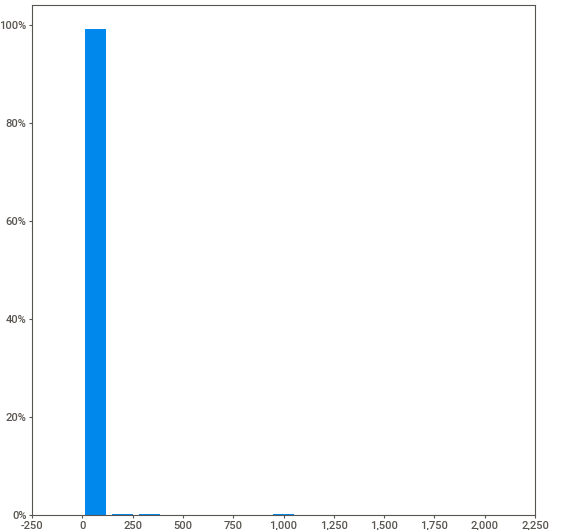
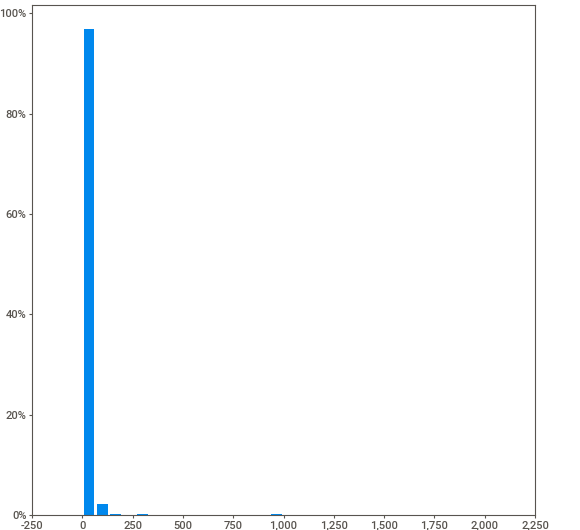
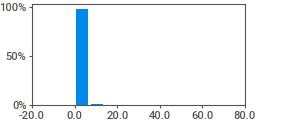
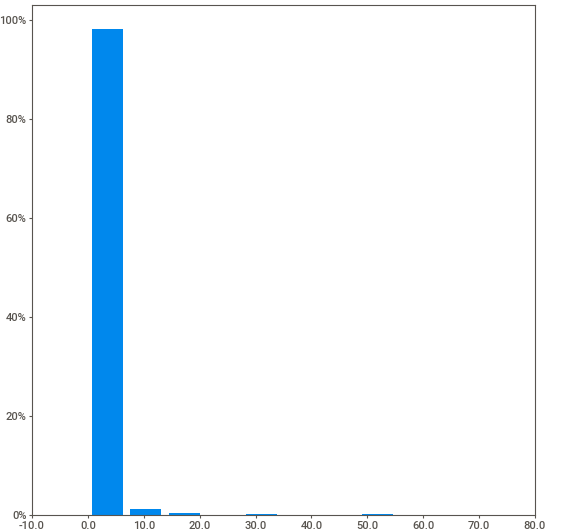
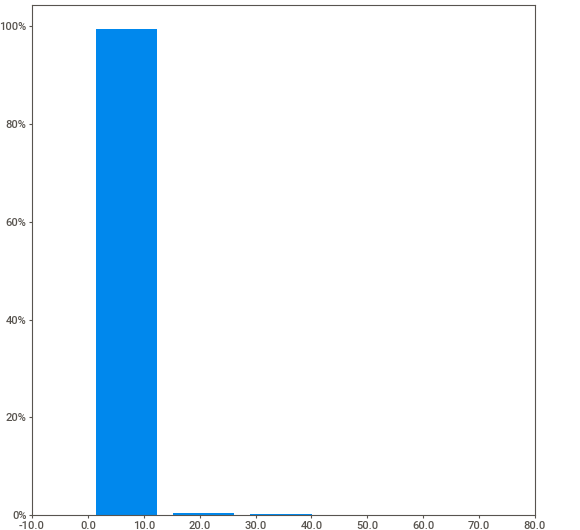
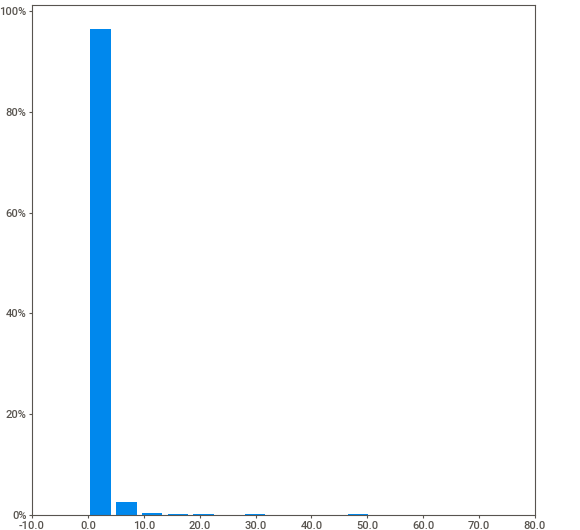
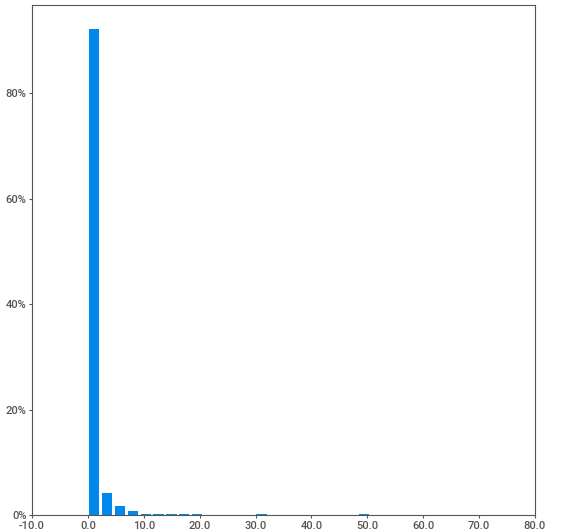
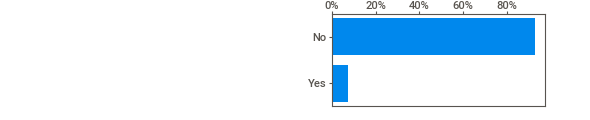
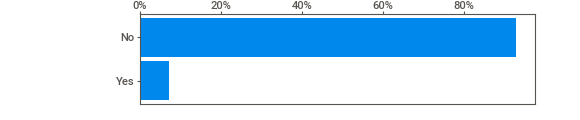
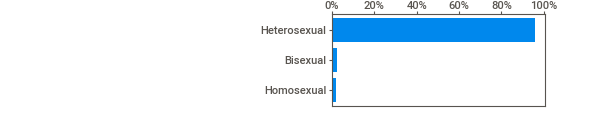
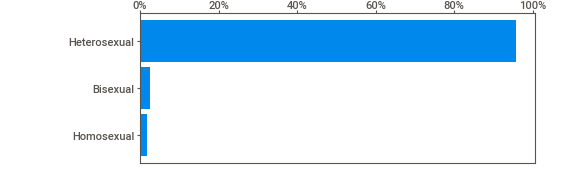
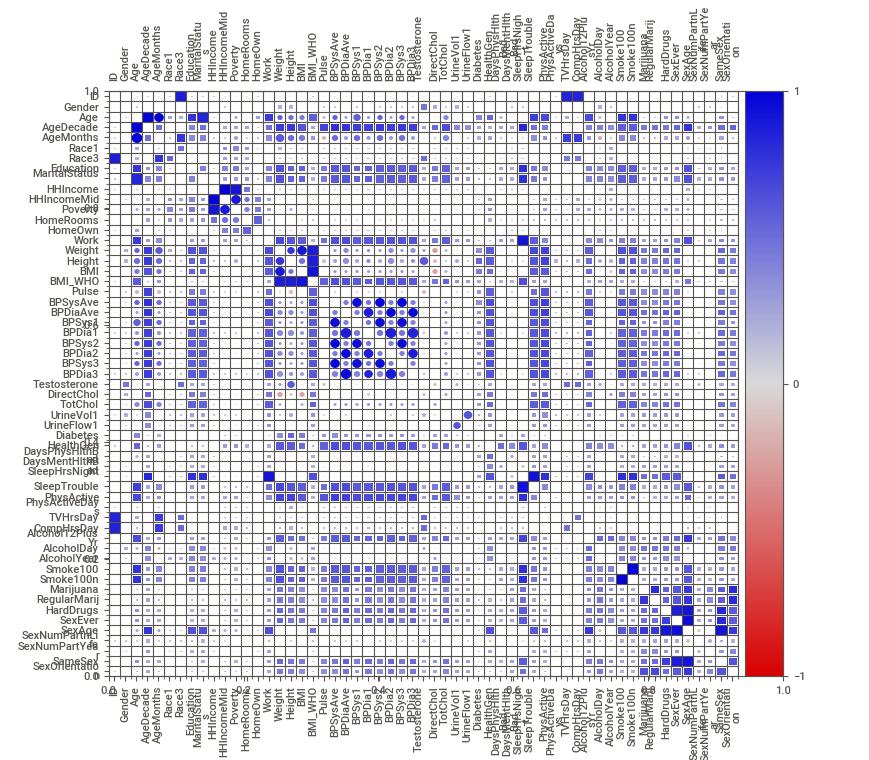
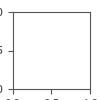

In [16]:
report = sv.analyze(tips)
report.show_notebook()

In [17]:
from google.colab import files
report.show_html('reporte_sweetviz.html')
files.download('reporte_sweetviz.html')

ModuleNotFoundError: No module named 'google'

Es posible comparar diferentes cortes de base. Por ejemplo, compare el subconjunto de fumadores y no fumadores:

In [ ]:
report = sv.compare_intra(tips,tips["smoker"] == "Yes",["Smoker","No Smoker"])
report.show_notebook()

O el subconjunto de clientes masculinos y femeninos:

In [ ]:
report = sv.compare_intra(tips,tips["sex"] == "Male",["Male","Female"])
report.show_notebook()

O los subgrupos de almuerzo y cena:

In [ ]:
report = sv.compare_intra(tips,tips["time"] == "Dinner",["Dinner","Lunch"])
report.show_notebook()

### Impacto de los valores perdidos

Para ilustrar la diferencia entre los mecanismos de valor perdido, simulemos diferentes mecanismos de valor perdido y comparemos bases de datos. Inicialmente haremos una copia de la base de datos:

In [ ]:
tips_NA = tips.copy()

Y luego seleccionamos una muestra aleatoria del 20%,

In [ ]:
sample = np.random.choice(list(tips_NA.index),int(len(tips)*0.2))
tips_NA.loc[sample,['total_bill','tip']] = np.nan

Comparemos los dos conjuntos de datos:

In [ ]:
report = sv.compare([tips,"Original"],[tips_NA,"Ausentes"])
report.show_notebook()

Una de las técnicas utilizadas para lidar con datos faltantes es eliminar las filas que contienen un valor faltante, utilizando la función `.dropna ()`.

In [ ]:
tips_removido = tips_NA.dropna()
report = sv.compare([tips,"Original"],[tips_removido,"Removido"])
report.show_notebook()

Datos faltantes con prioridad en las mesas para fumadores

In [ ]:
#crear una columnas de probabilidades, al inicio todos con probabilidad 1
p = np.ones(len(tips['smoker']))
# escojer la probabilidad de 0.5 para mesas de no fumadores
p[np.where(tips['smoker']=='No')] = 0.5
#calcular la probabilidad par cada item del dat set
p = p/sum(p)

In [ ]:
tips_NA2 = tips.copy()
sample = np.random.choice(list(tips_NA2.index),int(len(tips)*0.2), p = p)
tips_NA2.loc[sample,['total_bill','tip']] = np.nan

In [ ]:
report = sv.compare([tips_NA,"MCAR"],[tips_NA2,"MAR"])
report.show_notebook()

In [ ]:
tips_removido2 = tips_NA2.dropna()
report = sv.compare([tips_removido,"MCAR"],[tips_removido2,"MAR"])
report.show_notebook()

## 4.- Investigue alguna otra herramienta similar a sweetviz para hacer el EDA. Realice el EDA con la herramienta investigada. Y haga un análisis comparativo de ambas herramientas.